<a href="https://colab.research.google.com/github/stevej108/Data-Science-Projects/blob/main/Estimated_Asset_Protection_Impact_on_Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP Measures and the Impact on Traffic

This work represents an evaluation of AP measures at the store level, and their impact on traffic

## Loading the Data

In [3]:
import pandas as pd
import numpy as np

In [4]:
ap = pd.read_csv('/content/ap_store.csv')
ap.columns.to_list()

['Store',
 'SCA Receipt Store',
 'SCA Receipt Store (Date of rollout)',
 'Metering Store',
 'Metering Store (Date of rollout)',
 'Armed / Unarmed',
 'Automated Gate',
 'Gate Install Date',
 'PVMs',
 'PVM Install Date',
 'Trilogy Locks',
 'DMA']

In [5]:
print(ap.head())
print(ap.info())

   Store SCA Receipt Store SCA Receipt Store (Date of rollout) Metering Store  \
0    2.0                 Y                          2026-04-03              N   
1    3.0                 N                                 NaN              Y   
2    6.0                 Y                          2026-04-03              N   
3    8.0                 N                                 NaN              N   
4   12.0                 N                                 NaN              Y   

  Metering Store (Date of rollout) Armed / Unarmed Automated Gate  \
0                              NaN               N              N   
1                       2025-08-01               N              N   
2                              NaN               N              N   
3                              NaN               N              N   
4                       2024-05-02               N              N   

  Gate Install Date PVMs PVM Install Date Trilogy Locks  \
0               NaN    N              N

## Data Validation

In [6]:
# ============================================================
# 1. BASIC DMA / AP DIAGNOSTICS
# ============================================================

print(f"Rows: {len(ap):,}")
print(f"Unique DMAs: {ap['DMA'].nunique():,}")
print(f"Rows missing DMA: {ap['DMA'].isna().sum():,}")

# Number of records by DMA
dma_counts = (
    ap.groupby("DMA")
      .size()
      .reset_index(name="Rows")
      .sort_values("Rows", ascending=False)
)

display(dma_counts.head(20))


# Inspect the values used in the AP indicator columns
ap_flag_cols = [
    "SCA Receipt Store",
    "Metering Store",
    "Armed / Unarmed",
    "Automated Gate",
    "PVMs",
    "Trilogy Locks",
]

for col in ap_flag_cols:
    print(f"\n{col}")
    print(ap[col].value_counts(dropna=False))

Rows: 1,362
Unique DMAs: 167
Rows missing DMA: 146


,DMA,Rows
101,"New York, NY",99
86,"Los Angeles, CA",65
28,"Chicago, IL",47
65,"Houston, TX",46
111,"Philadelphia, PA",42
93,"Miami-Ft. Lauderdale, FL",40
7,"Atlanta, GA",33
37,"Dallas-Ft. Worth, TX",33
117,Puerto Rico,30
157,"Washington, DC (Hagerstown, MD)",26



SCA Receipt Store
SCA Receipt Store
N                   883
Y                   448
Pending Approval     31
Name: count, dtype: int64

Metering Store
Metering Store
N    938
Y    424
Name: count, dtype: int64

Armed / Unarmed
Armed / Unarmed
N             1337
Unarmed         16
Armed            6
ODS              2
Supervisor       1
Name: count, dtype: int64

Automated Gate
Automated Gate
N    1328
Y      34
Name: count, dtype: int64

PVMs
PVMs
N    1262
Y     100
Name: count, dtype: int64

Trilogy Locks
Trilogy Locks
Y    694
N    668
Name: count, dtype: int64


In [7]:
# ============================================================
# 2. CHECK STORE-LEVEL GRAIN
# ============================================================

print(f"Total rows: {len(ap):,}")
print(f"Non-null Store IDs: {ap['Store'].notna().sum():,}")
print(f"Unique Store IDs: {ap['Store'].nunique():,}")
print(f"Duplicate Store IDs: {ap['Store'].duplicated().sum():,}")

# Rows without a Store ID
display(
    ap.loc[ap["Store"].isna(), [
        "Store",
        "DMA",
        "SCA Receipt Store",
        "Metering Store",
        "Armed / Unarmed",
        "Automated Gate",
        "PVMs",
        "Trilogy Locks"
    ]].head(20)
)

Total rows: 1,362
Non-null Store IDs: 1,334
Unique Store IDs: 1,334
Duplicate Store IDs: 27


,Store,DMA,SCA Receipt Store,Metering Store,Armed / Unarmed,Automated Gate,PVMs,Trilogy Locks
1334,NaN,NaN,N,N,N,N,N,N
1335,NaN,NaN,N,N,N,N,N,N
1336,NaN,NaN,N,N,N,N,N,N
1337,NaN,NaN,N,N,N,N,N,N
1338,NaN,NaN,N,N,N,N,N,N
1339,NaN,NaN,N,N,N,N,N,N
1340,NaN,NaN,N,N,N,N,N,N
1341,NaN,NaN,N,N,N,N,N,N
1342,NaN,NaN,N,N,N,N,N,N
1343,NaN,NaN,N,N,N,N,N,N


In [8]:
# ============================================================
# 3. CLEAN IMPLEMENTATION DATES
# ============================================================

date_cols = [
    "SCA Receipt Store (Date of rollout)",
    "Metering Store (Date of rollout)",
    "Gate Install Date",
    "PVM Install Date",
]

for col in date_cols:
    ap[col] = pd.to_datetime(ap[col], errors="coerce")

# Check conversion
print(ap[date_cols].dtypes)

for col in date_cols:
    print(
        f"{col}: "
        f"{ap[col].notna().sum():,} dates | "
        f"{ap[col].min()} to {ap[col].max()}"
    )

SCA Receipt Store (Date of rollout)    datetime64[ns]
Metering Store (Date of rollout)       datetime64[ns]
Gate Install Date                      datetime64[ns]
PVM Install Date                       datetime64[ns]
dtype: object
SCA Receipt Store (Date of rollout): 448 dates | 2025-03-24 00:00:00 to 2026-07-17 00:00:00
Metering Store (Date of rollout): 424 dates | 2023-08-01 00:00:00 to 2026-07-22 00:00:00
Gate Install Date: 33 dates | 2024-09-27 00:00:00 to 2025-11-21 00:00:00
PVM Install Date: 50 dates | 2026-06-11 00:00:00 to 2026-07-30 00:00:00


## Cleaning and Feature Engineering

In [9]:
# ============================================================
# CLEAN AP CATEGORICAL VALUES
# ============================================================

# SCA Receipt Store
# Treat Pending Approval as AP presence
ap["SCA Receipt Store"] = (
    ap["SCA Receipt Store"]
    .astype("string")
    .str.strip()
    .replace({
        "Pending Approval": "Y"
    })
)

# Armed / Unarmed
# Preserve Armed and Unarmed categories, but standardize
# ODS and Supervisor as AP presence
ap["Armed / Unarmed"] = (
    ap["Armed / Unarmed"]
    .astype("string")
    .str.strip()
    .replace({
        "ODS": "Y",
        "Supervisor": "Y"
    })
)

In [10]:
# ============================================================
# 4. CREATE AP INDICATORS
# ============================================================

yes_no_cols = {
    "SCA Receipt Store": "SCA_Receipt",
    "Metering Store": "Metering",
    "Automated Gate": "Automated_Gate",
    "PVMs": "PVM",
    "Trilogy Locks": "Trilogy_Locks",
}

# Security personnel AP indicator
ap["Security_Personnel"] = (
    ap["Armed / Unarmed"]
    .isin(["Armed", "Unarmed", "Y"])
    .astype(int)
)

ap["Armed_Security"] = (
    ap["Armed / Unarmed"]
    .eq("Armed")
    .astype(int)
)

ap["Unarmed_Security"] = (
    ap["Armed / Unarmed"]
    .eq("Unarmed")
    .astype(int)
)

for source_col, new_col in yes_no_cols.items():
    ap[new_col] = (
        ap[source_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("y")
        .astype(int)
    )

In [11]:
# ============================================================
# 5. DMA-LEVEL AP COVERAGE
# ============================================================

indicator_cols = [
    "SCA_Receipt",
    "Metering",
    "Security_Personnel",
    "Automated_Gate",
    "PVM",
    "Trilogy_Locks",
]

dma_ap = (
    ap.dropna(subset=["DMA"])
      .groupby("DMA")
      .agg(
          Stores=("Store", "nunique"),
          SCA_Receipt_Stores=("SCA_Receipt", "sum"),
          Metering_Stores=("Metering", "sum"),
          Security_Personnel_Stores=("Security_Personnel", "sum"),
          Automated_Gate_Stores=("Automated_Gate", "sum"),
          PVM_Stores=("PVM", "sum"),
          Trilogy_Lock_Stores=("Trilogy_Locks", "sum"),
      )
      .reset_index()
)

# Coverage percentages
dma_ap["SCA_Receipt_Pct"] = (
    dma_ap["SCA_Receipt_Stores"] / dma_ap["Stores"]
)

dma_ap["Metering_Pct"] = (
    dma_ap["Metering_Stores"] / dma_ap["Stores"]
)

dma_ap["Security_Personnel_Pct"] = (
    dma_ap["Security_Personnel_Stores"] / dma_ap["Stores"]
)

dma_ap["Automated_Gate_Pct"] = (
    dma_ap["Automated_Gate_Stores"] / dma_ap["Stores"]
)

dma_ap["PVM_Pct"] = (
    dma_ap["PVM_Stores"] / dma_ap["Stores"]
)

dma_ap["Trilogy_Lock_Pct"] = (
    dma_ap["Trilogy_Lock_Stores"] / dma_ap["Stores"]
)

dma_ap = (
    dma_ap
    .sort_values("Stores", ascending=False)
    .reset_index(drop=True)
)


display_cols = [
    "DMA",
    "Stores",
    "SCA_Receipt_Stores",
    "SCA_Receipt_Pct",
    "Metering_Stores",
    "Metering_Pct",
    "Security_Personnel_Stores",
    "Security_Personnel_Pct",
    "Automated_Gate_Stores",
    "Automated_Gate_Pct",
    "PVM_Stores",
    "PVM_Pct",
    "Trilogy_Lock_Stores",
    "Trilogy_Lock_Pct",
]

display(
    dma_ap[display_cols].style.format({
        "SCA_Receipt_Pct": "{:.1%}",
        "Metering_Pct": "{:.1%}",
        "Security_Personnel_Pct": "{:.1%}",
        "Automated_Gate_Pct": "{:.1%}",
        "PVM_Pct": "{:.1%}",
        "Trilogy_Lock_Pct": "{:.1%}",
    })
)
display(dma_ap.head(20))

,DMA,Stores,SCA_Receipt_Stores,SCA_Receipt_Pct,Metering_Stores,Metering_Pct,Security_Personnel_Stores,Security_Personnel_Pct,Automated_Gate_Stores,Automated_Gate_Pct,PVM_Stores,PVM_Pct,Trilogy_Lock_Stores,Trilogy_Lock_Pct
0,"New York, NY",99,29,29.3%,54,54.5%,20,20.2%,5,5.1%,22,22.2%,81,81.8%
1,"Los Angeles, CA",65,16,24.6%,45,69.2%,0,0.0%,1,1.5%,7,10.8%,56,86.2%
2,"Chicago, IL",47,18,38.3%,13,27.7%,2,4.3%,0,0.0%,1,2.1%,25,53.2%
3,"Houston, TX",46,22,47.8%,19,41.3%,0,0.0%,1,2.2%,5,10.9%,26,56.5%
4,"Philadelphia, PA",42,13,31.0%,19,45.2%,1,2.4%,0,0.0%,4,9.5%,26,61.9%
5,"Miami-Ft. Lauderdale, FL",40,25,62.5%,9,22.5%,0,0.0%,1,2.5%,4,10.0%,21,52.5%
6,"Atlanta, GA",33,14,42.4%,3,9.1%,0,0.0%,1,3.0%,0,0.0%,18,54.5%
7,"Dallas-Ft. Worth, TX",33,15,45.5%,12,36.4%,0,0.0%,3,9.1%,1,3.0%,12,36.4%
8,Puerto Rico,30,19,63.3%,4,13.3%,0,0.0%,0,0.0%,2,6.7%,0,0.0%
9,"Washington, DC (Hagerstown, MD)",26,11,42.3%,12,46.2%,1,3.8%,0,0.0%,3,11.5%,16,61.5%


,DMA,Stores,SCA_Receipt_Stores,Metering_Stores,Security_Personnel_Stores,Automated_Gate_Stores,PVM_Stores,Trilogy_Lock_Stores,SCA_Receipt_Pct,Metering_Pct,Security_Personnel_Pct,Automated_Gate_Pct,PVM_Pct,Trilogy_Lock_Pct
0,"New York, NY",99,29,54,20,5,22,81,0.292929,0.545455,0.202020,0.050505,0.222222,0.818182
1,"Los Angeles, CA",65,16,45,0,1,7,56,0.246154,0.692308,0.000000,0.015385,0.107692,0.861538
2,"Chicago, IL",47,18,13,2,0,1,25,0.382979,0.276596,0.042553,0.000000,0.021277,0.531915
3,"Houston, TX",46,22,19,0,1,5,26,0.478261,0.413043,0.000000,0.021739,0.108696,0.565217
4,"Philadelphia, PA",42,13,19,1,0,4,26,0.309524,0.452381,0.023810,0.000000,0.095238,0.619048
5,"Miami-Ft. Lauderdale, FL",40,25,9,0,1,4,21,0.625000,0.225000,0.000000,0.025000,0.100000,0.525000
6,"Atlanta, GA",33,14,3,0,1,0,18,0.424242,0.090909,0.000000,0.030303,0.000000,0.545455
7,"Dallas-Ft. Worth, TX",33,15,12,0,3,1,12,0.454545,0.363636,0.000000,0.090909,0.030303,0.363636
8,Puerto Rico,30,19,4,0,0,2,0,0.633333,0.133333,0.000000,0.000000,0.066667,0.000000
9,"Washington, DC (Hagerstown, MD)",26,11,12,1,0,3,16,0.423077,0.461538,0.038462,0.000000,0.115385,0.615385


In [12]:
# ============================================================
# 6. OVERALL AP COVERAGE BY DMA
# ============================================================

pct_cols = [
    "SCA_Receipt_Pct",
    "Metering_Pct",
    "Security_Personnel_Pct",
    "Automated_Gate_Pct",
    "PVM_Pct",
    "Trilogy_Lock_Pct",
]

# Average percentage of AP measures present across stores
# Used primarily to order the plot
dma_ap["Avg_AP_Coverage"] = dma_ap[pct_cols].mean(axis=1)

dma_ap_plot = (
    dma_ap
    .sort_values("Avg_AP_Coverage", ascending=True)
    .copy()
)

display(
    dma_ap_plot[
        ["DMA", "Stores", "Avg_AP_Coverage"] + pct_cols
    ].tail(20)
)

,DMA,Stores,Avg_AP_Coverage,SCA_Receipt_Pct,Metering_Pct,Security_Personnel_Pct,Automated_Gate_Pct,PVM_Pct,Trilogy_Lock_Pct
159,"Savannah, GA",1,0.333333,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000
101,"Chico-Redding, CA",2,0.333333,0.500000,0.500000,0.00000,0.000000,0.000000,1.000000
97,"Rockford, IL",2,0.333333,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000
113,"Montgomery-Selma, AL",2,0.333333,0.500000,0.500000,0.00000,0.000000,0.000000,1.000000
121,"Springfield-Holyoke, MA",2,0.333333,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000
87,"Anchorage, AK",2,0.333333,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000
72,"Syracuse, NY",3,0.333333,0.666667,0.333333,0.00000,0.000000,0.333333,0.666667
69,"Reno, NV",4,0.333333,0.500000,0.500000,0.00000,0.000000,0.000000,1.000000
67,"Rochester, NY",4,0.333333,0.750000,0.250000,0.00000,0.000000,0.000000,1.000000
56,"Albuquerque-Santa Fe, NM",5,0.333333,0.200000,0.800000,0.00000,0.000000,0.000000,1.000000


In [13]:
dma_ap.describe().T

,count,mean,std,min,25%,50%,75%,max
Stores,167.0,7.281437,12.168439,1.0,1.000000,3.000000,8.000000,99.00000
SCA_Receipt_Stores,167.0,2.574850,4.588366,0.0,0.000000,1.000000,3.000000,29.00000
Metering_Stores,167.0,2.485030,6.222633,0.0,0.000000,0.000000,2.000000,54.00000
Security_Personnel_Stores,167.0,0.149701,1.558609,0.0,0.000000,0.000000,0.000000,20.00000
Automated_Gate_Stores,167.0,0.203593,0.586381,0.0,0.000000,0.000000,0.000000,5.00000
PVM_Stores,167.0,0.598802,2.074109,0.0,0.000000,0.000000,0.000000,22.00000
Trilogy_Lock_Stores,167.0,3.850299,8.714777,0.0,0.000000,1.000000,4.000000,81.00000
SCA_Receipt_Pct,167.0,0.330133,0.315210,0.0,0.000000,0.309524,0.500000,1.00000
Metering_Pct,167.0,0.220942,0.281775,0.0,0.000000,0.000000,0.420807,1.00000
Security_Personnel_Pct,167.0,0.002336,0.017477,0.0,0.000000,0.000000,0.000000,0.20202


In [14]:
# ============================================================
# COMPARE DMA STORE-COUNT THRESHOLDS
# ============================================================

thresholds = [1, 3, 5, 8, 10]

threshold_summary = []

total_dmas = len(dma_ap)
total_stores = dma_ap["Stores"].sum()

for threshold in thresholds:

    temp = dma_ap.loc[dma_ap["Stores"] >= threshold]

    threshold_summary.append({
        "Min_Stores": threshold,
        "DMAs_Retained": len(temp),
        "DMA_Retention_Pct": len(temp) / total_dmas,
        "Stores_Retained": temp["Stores"].sum(),
        "Store_Retention_Pct": temp["Stores"].sum() / total_stores,
        "Median_DMA_Size": temp["Stores"].median(),
        "Mean_DMA_Size": temp["Stores"].mean(),
    })

threshold_summary = pd.DataFrame(threshold_summary)

display(
    threshold_summary.style.format({
        "DMA_Retention_Pct": "{:.1%}",
        "Store_Retention_Pct": "{:.1%}",
        "Median_DMA_Size": "{:.1f}",
        "Mean_DMA_Size": "{:.1f}",
    })
)

,Min_Stores,DMAs_Retained,DMA_Retention_Pct,Stores_Retained,Store_Retention_Pct,Median_DMA_Size,Mean_DMA_Size
0,1,167,100.0%,1216,100.0%,3.0,7.3
1,3,86,51.5%,1097,90.2%,8.0,12.8
2,5,60,35.9%,1009,83.0%,10.0,16.8
3,8,45,26.9%,921,75.7%,13.0,20.5
4,10,35,21.0%,836,68.8%,16.0,23.9


In [15]:
# ============================================================
# FILTER DMA-LEVEL DATA BY MINIMUM STORE COUNT
# ============================================================

MIN_DMA_STORES = 5

dma_ap_filtered = (
    dma_ap.loc[dma_ap["Stores"] >= MIN_DMA_STORES]
          .copy()
          .reset_index(drop=True)
)

print(f"All DMAs: {len(dma_ap):,}")
print(f"DMAs with >= {MIN_DMA_STORES} stores: {len(dma_ap_filtered):,}")
print(
    f"DMAs excluded: "
    f"{len(dma_ap) - len(dma_ap_filtered):,}"
)

print(
    f"\nStores represented before filter: "
    f"{dma_ap['Stores'].sum():,.0f}"
)

print(
    f"Stores represented after filter: "
    f"{dma_ap_filtered['Stores'].sum():,.0f}"
)

All DMAs: 167
DMAs with >= 5 stores: 60
DMAs excluded: 107

Stores represented before filter: 1,216
Stores represented after filter: 1,009


In [16]:
stores_total = dma_ap["Stores"].sum()
stores_retained = dma_ap_filtered["Stores"].sum()

store_retention_pct = stores_retained / stores_total

print(
    f"Store coverage retained: "
    f"{store_retention_pct:.1%}"
)

Store coverage retained: 83.0%


## EDA

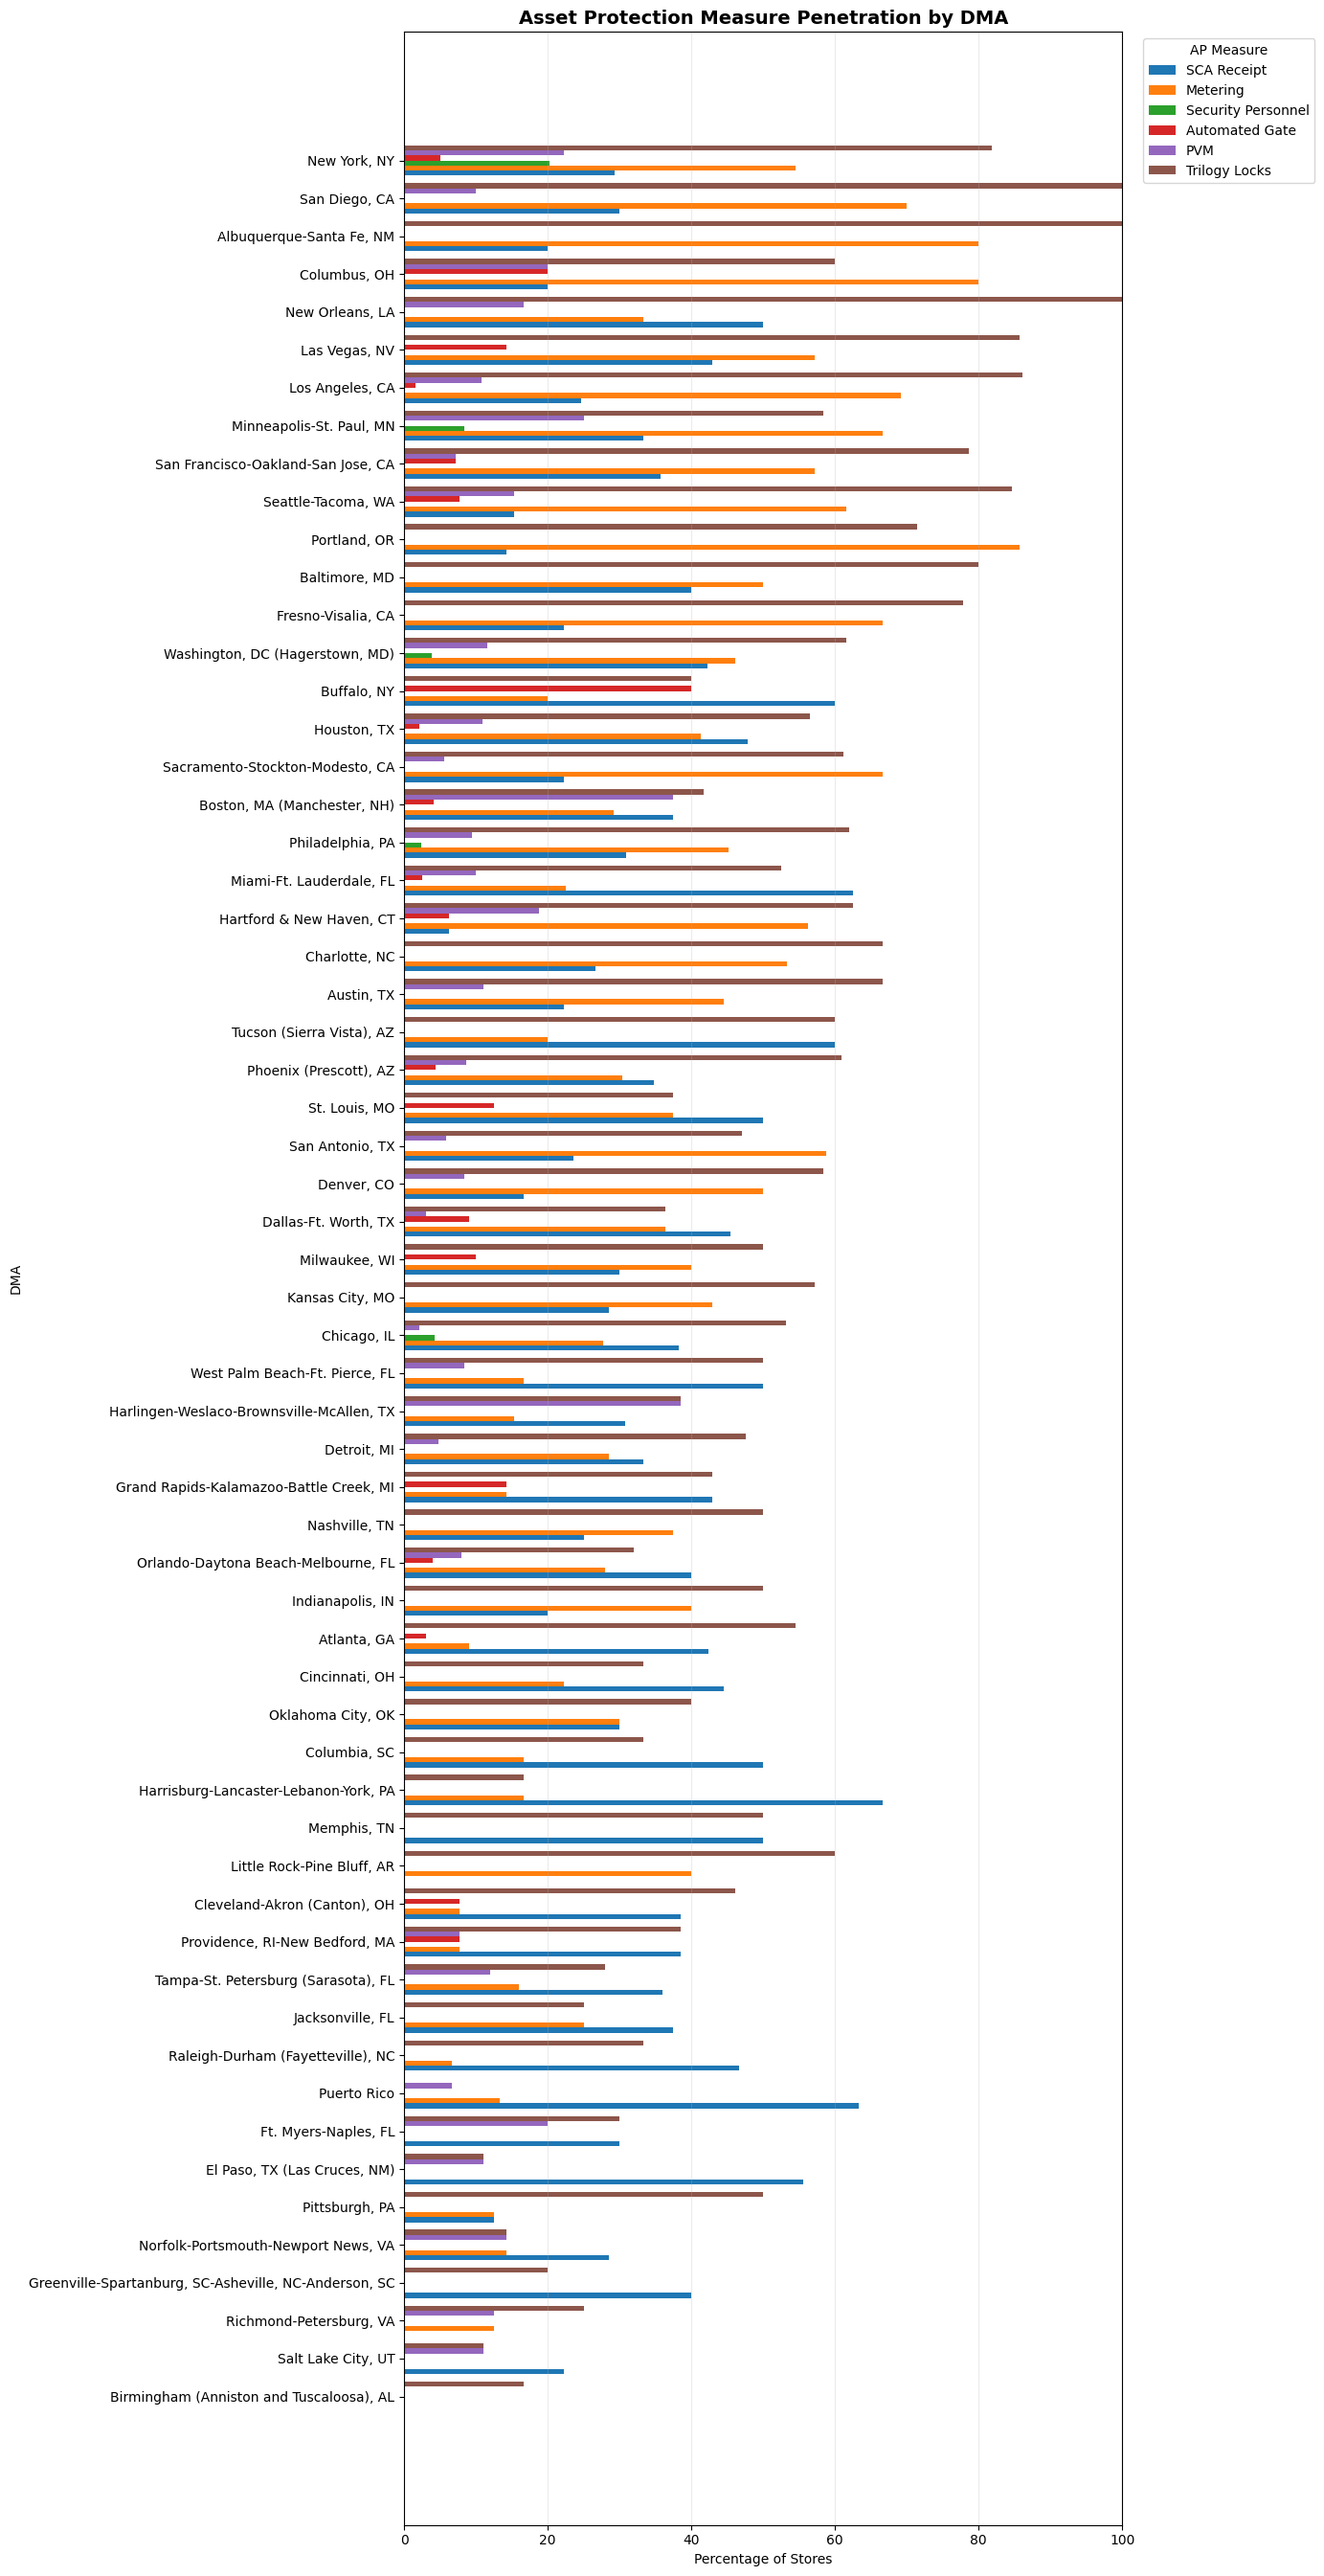

In [17]:
# ============================================================
# AP MEASURE PENETRATION BY DMA
# ============================================================

dma_ap_plot = (
    dma_ap_filtered
    .sort_values("Avg_AP_Coverage", ascending=True)
    .copy()
)

import matplotlib.pyplot as plt
import numpy as np

plot_cols = {
    "SCA_Receipt_Pct": "SCA Receipt",
    "Metering_Pct": "Metering",
    "Security_Personnel_Pct": "Security Personnel",
    "Automated_Gate_Pct": "Automated Gate",
    "PVM_Pct": "PVM",
    "Trilogy_Lock_Pct": "Trilogy Locks",
}

fig, ax = plt.subplots(
    figsize=(14, max(8, len(dma_ap_plot) * 0.45))
)

y = np.arange(len(dma_ap_plot))
n_measures = len(plot_cols)
bar_height = 0.8 / n_measures

for i, (col, label) in enumerate(plot_cols.items()):

    offset = (i - (n_measures - 1) / 2) * bar_height

    ax.barh(
        y + offset,
        dma_ap_plot[col] * 100,
        height=bar_height,
        label=label
    )

ax.set_yticks(y)
ax.set_yticklabels(dma_ap_plot["DMA"])

ax.set_xlabel("Percentage of Stores")
ax.set_ylabel("DMA")

ax.set_title(
    "Asset Protection Measure Penetration by DMA",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlim(0, 100)

ax.legend(
    title="AP Measure",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

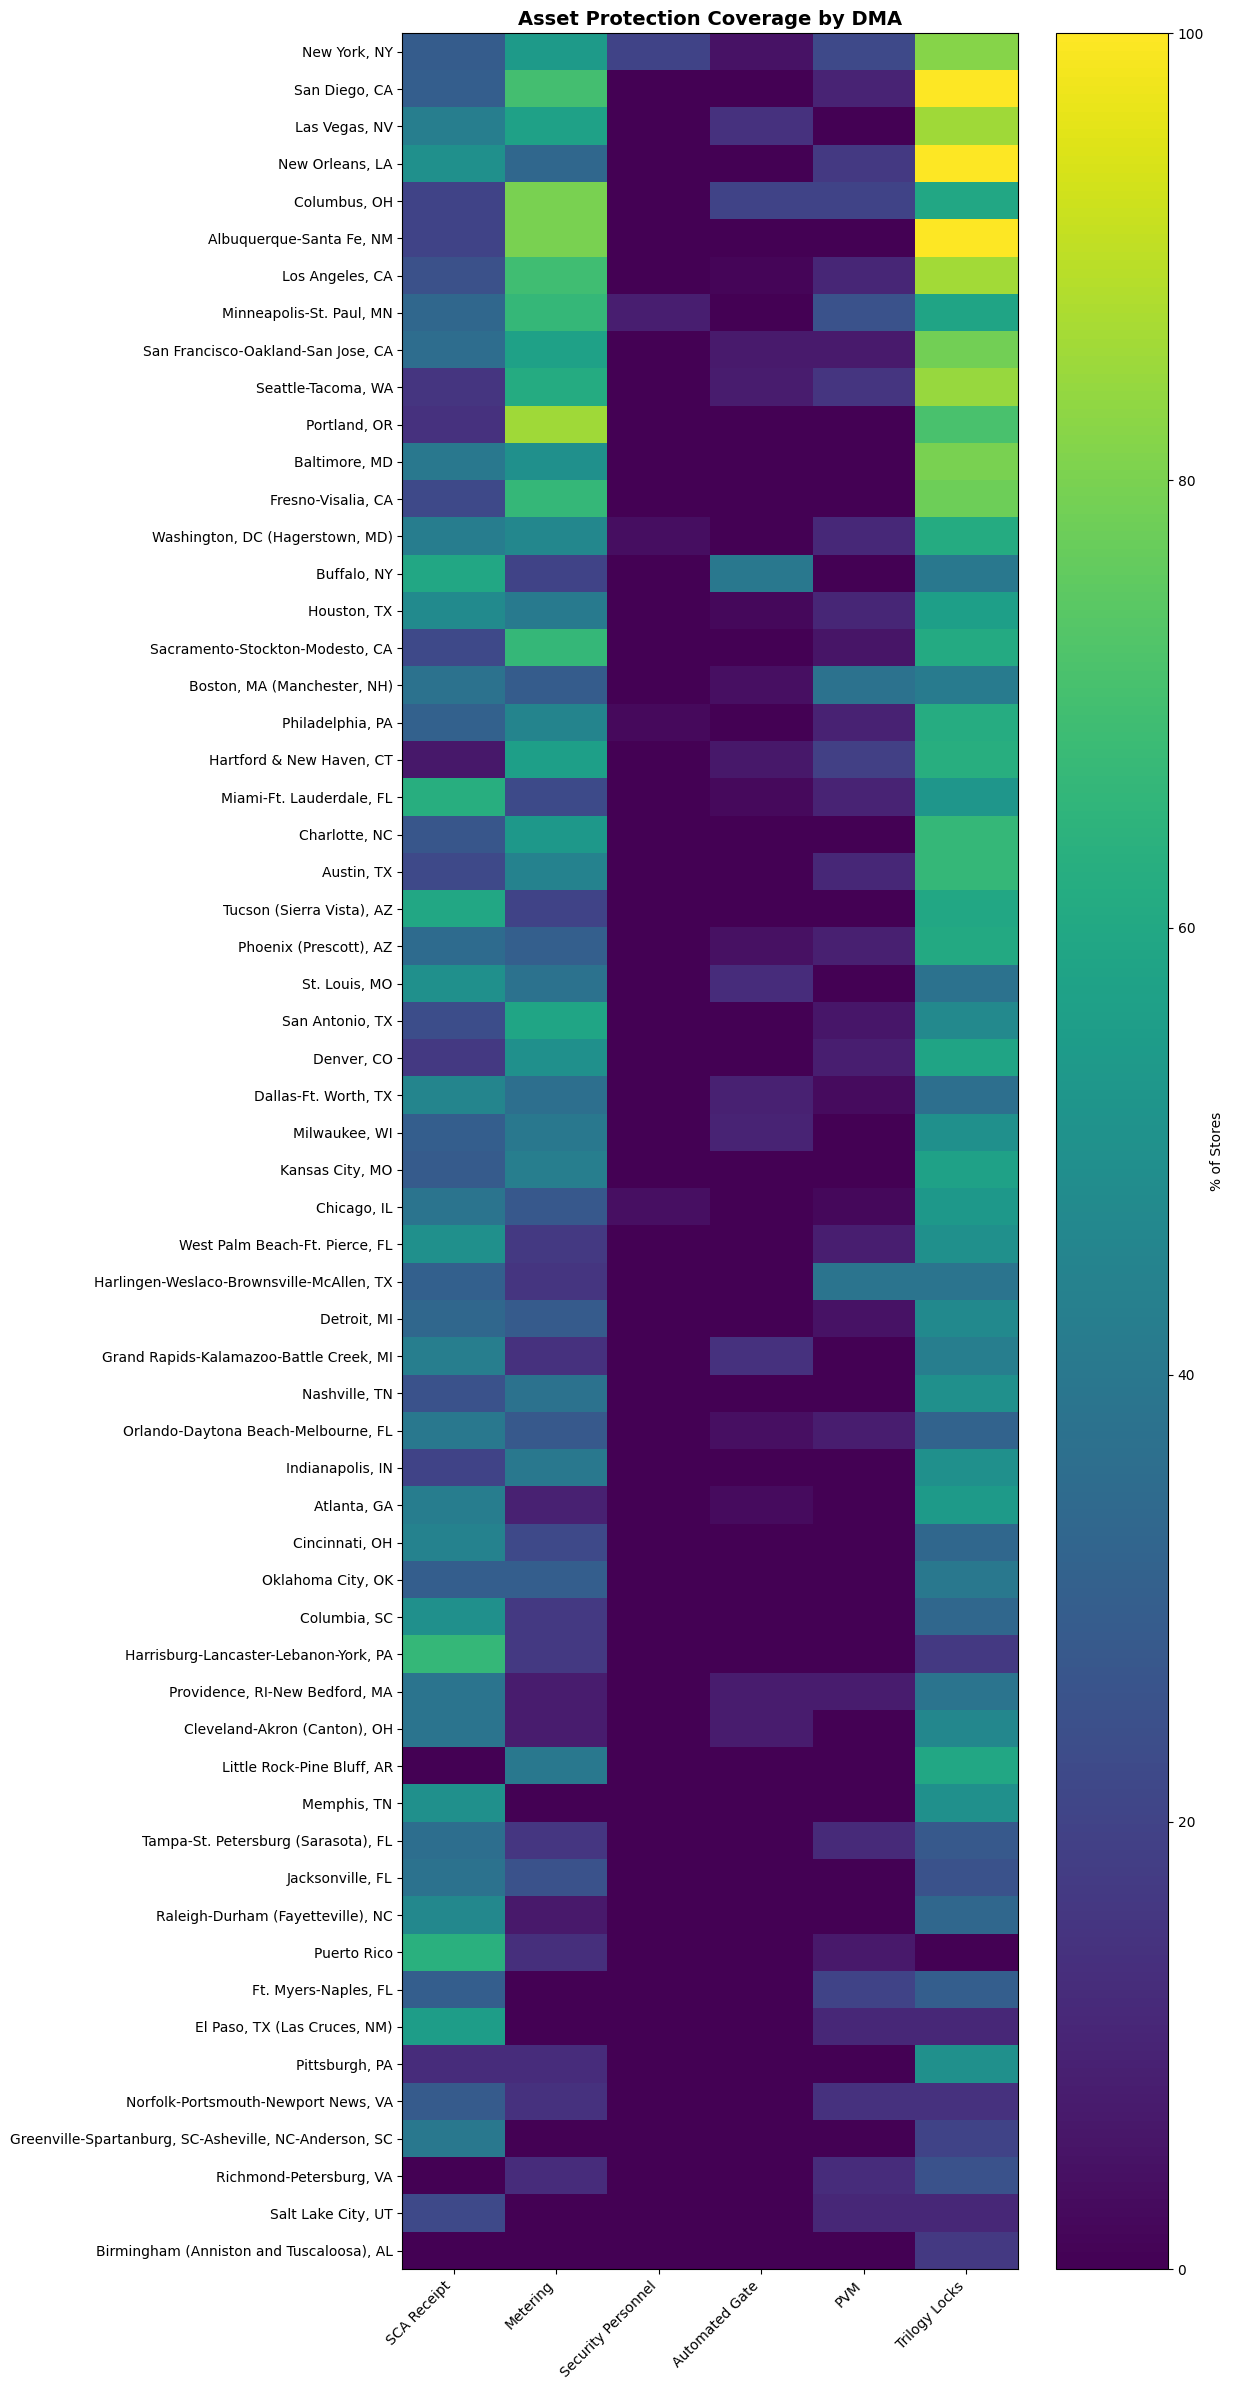

In [18]:
# ============================================================
# AP COVERAGE HEATMAP BY DMA
# ============================================================

import matplotlib.pyplot as plt

heatmap_data = (
    dma_ap_plot
    .sort_values("Avg_AP_Coverage", ascending=False)
    .set_index("DMA")[pct_cols]
    * 100
)

# Cleaner column names
heatmap_data.columns = [
    "SCA Receipt",
    "Metering",
    "Security Personnel",
    "Automated Gate",
    "PVM",
    "Trilogy Locks",
]

fig, ax = plt.subplots(
    figsize=(12, max(8, len(heatmap_data) * 0.4))
)

im = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("% of Stores")

ax.set_title(
    "Asset Protection Coverage by DMA",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# RANKED DMA AP COVERAGE PLOT
# ============================================================

def plot_dma_ap_coverage(
    df,
    pct_col,
    title,
    min_stores=1,
    top_n=None
):
    """
    Plot DMA-level penetration for a selected AP measure.

    Parameters
    ----------
    df : DataFrame
        DMA-level AP summary.
    pct_col : str
        Percentage column to plot.
    title : str
        Figure title.
    min_stores : int
        Minimum number of stores required in DMA.
    top_n : int or None
        Optionally restrict to top N DMAs.
    """

    plot_df = (
        df.loc[df["Stores"] >= min_stores]
        .sort_values(pct_col, ascending=False)
        .copy()
    )

    if top_n is not None:
        plot_df = plot_df.head(top_n)

    # Reverse for horizontal plotting
    plot_df = plot_df.sort_values(pct_col)

    fig, ax = plt.subplots(
        figsize=(10, max(6, len(plot_df) * 0.35))
    )

    ax.barh(
        plot_df["DMA"],
        plot_df[pct_col] * 100
    )

    ax.set_xlabel("Percentage of Stores")
    ax.set_ylabel("DMA")
    ax.set_xlim(0, 100)

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(axis="x", alpha=0.25)

    # Add percentage labels
    for i, value in enumerate(plot_df[pct_col] * 100):
        ax.text(
            value + 1,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

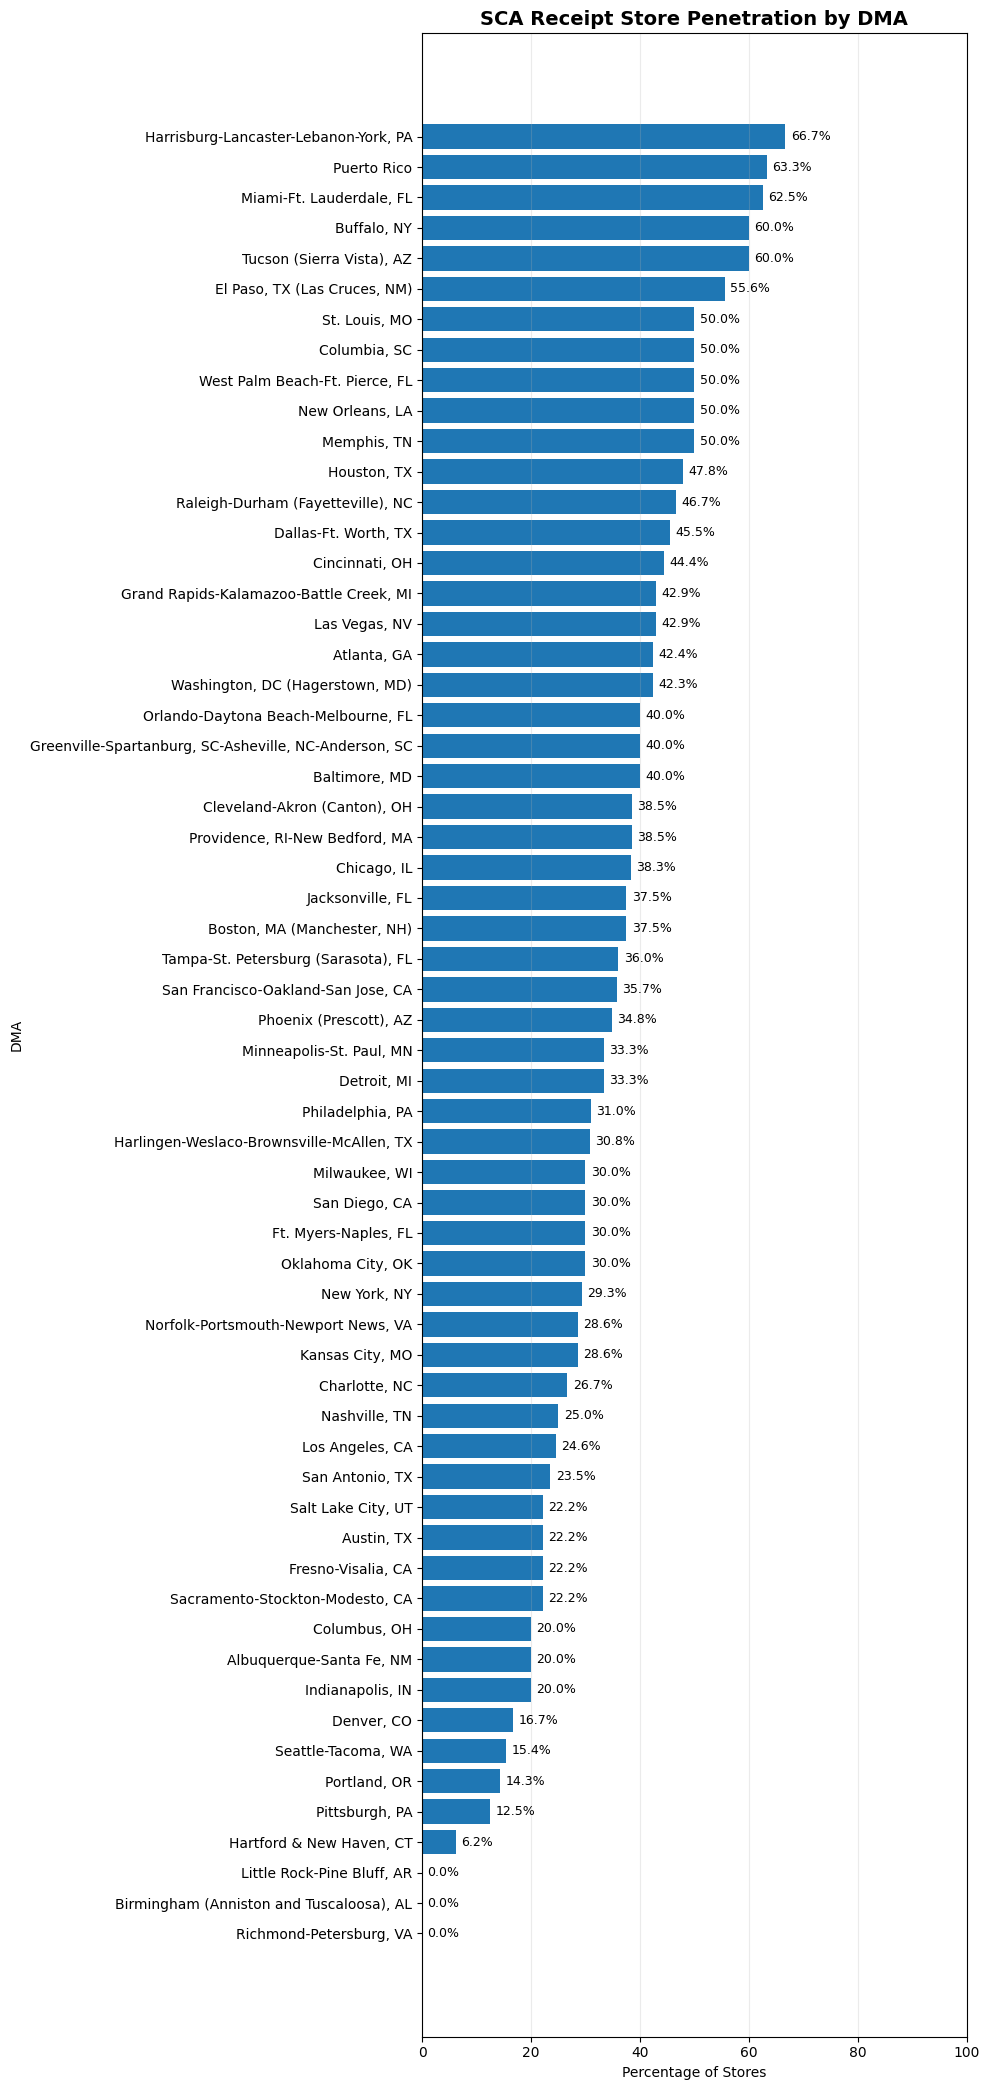

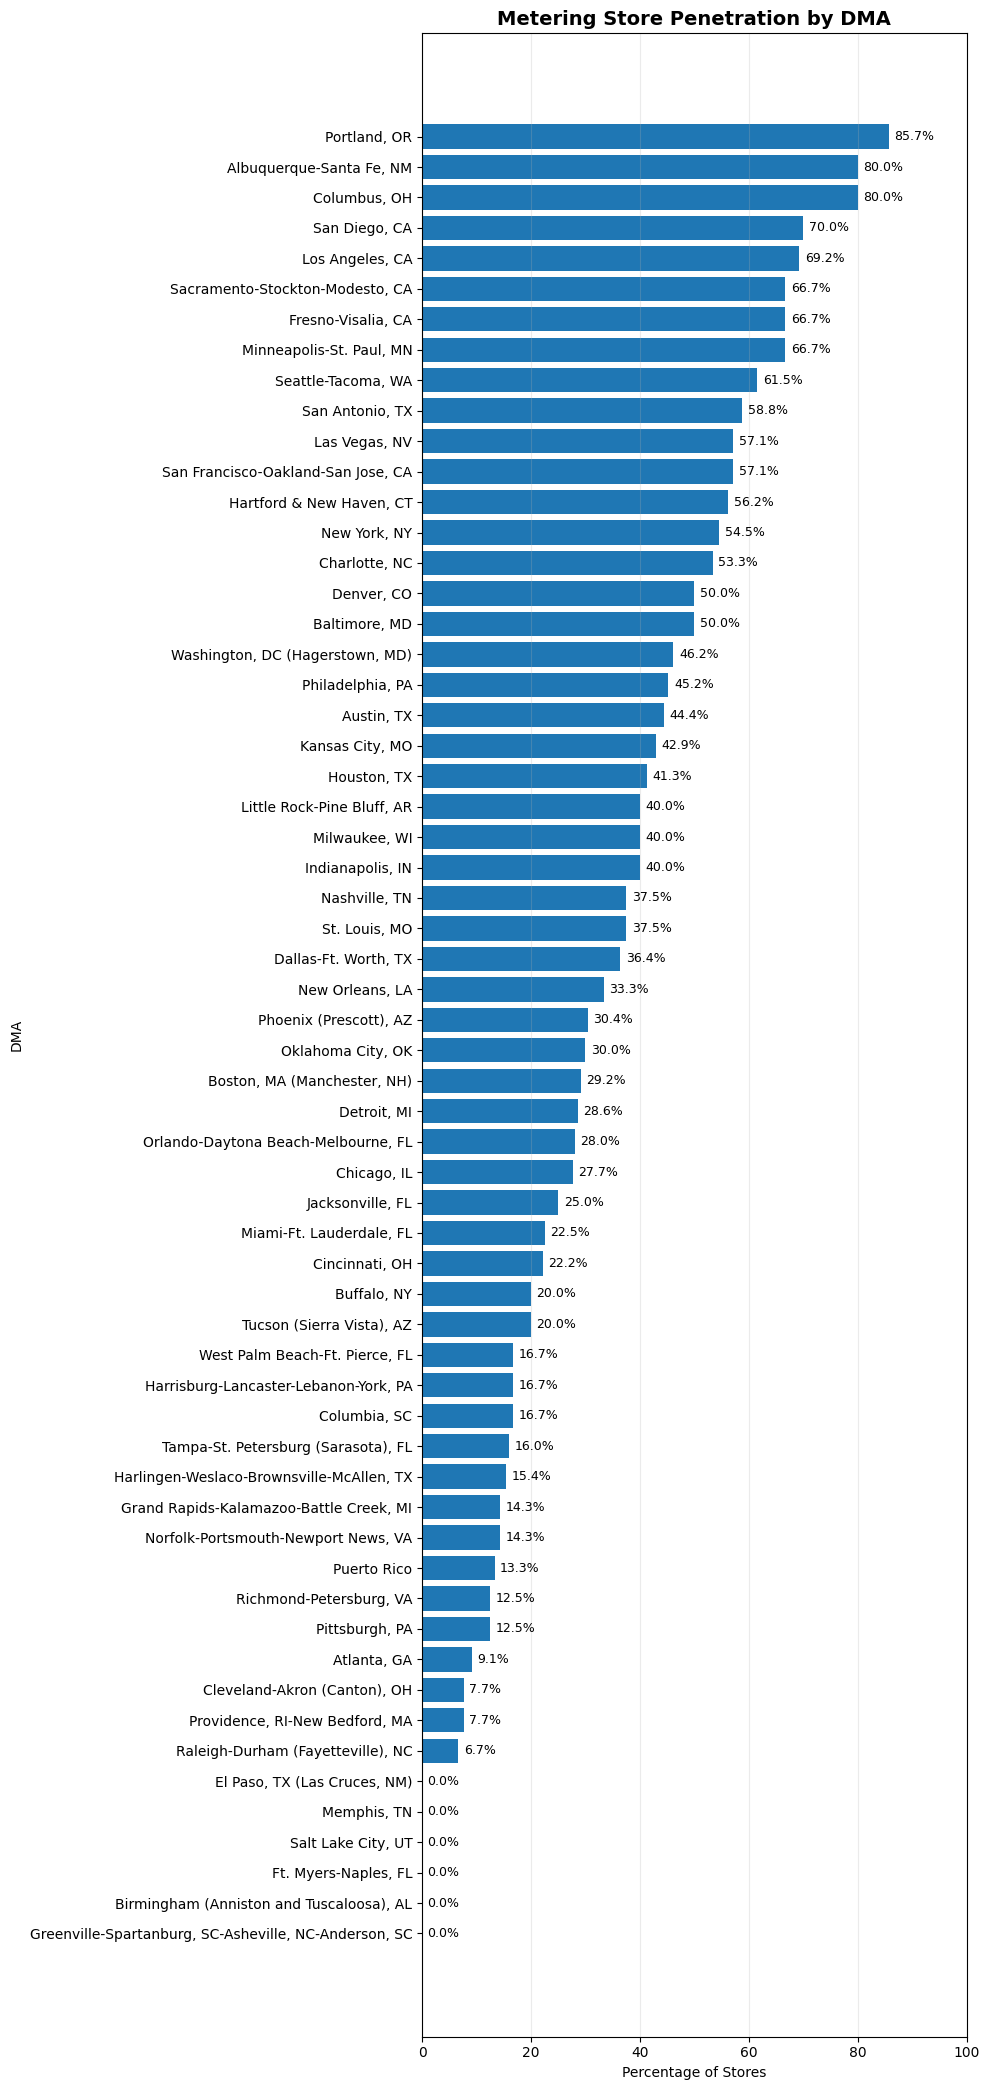

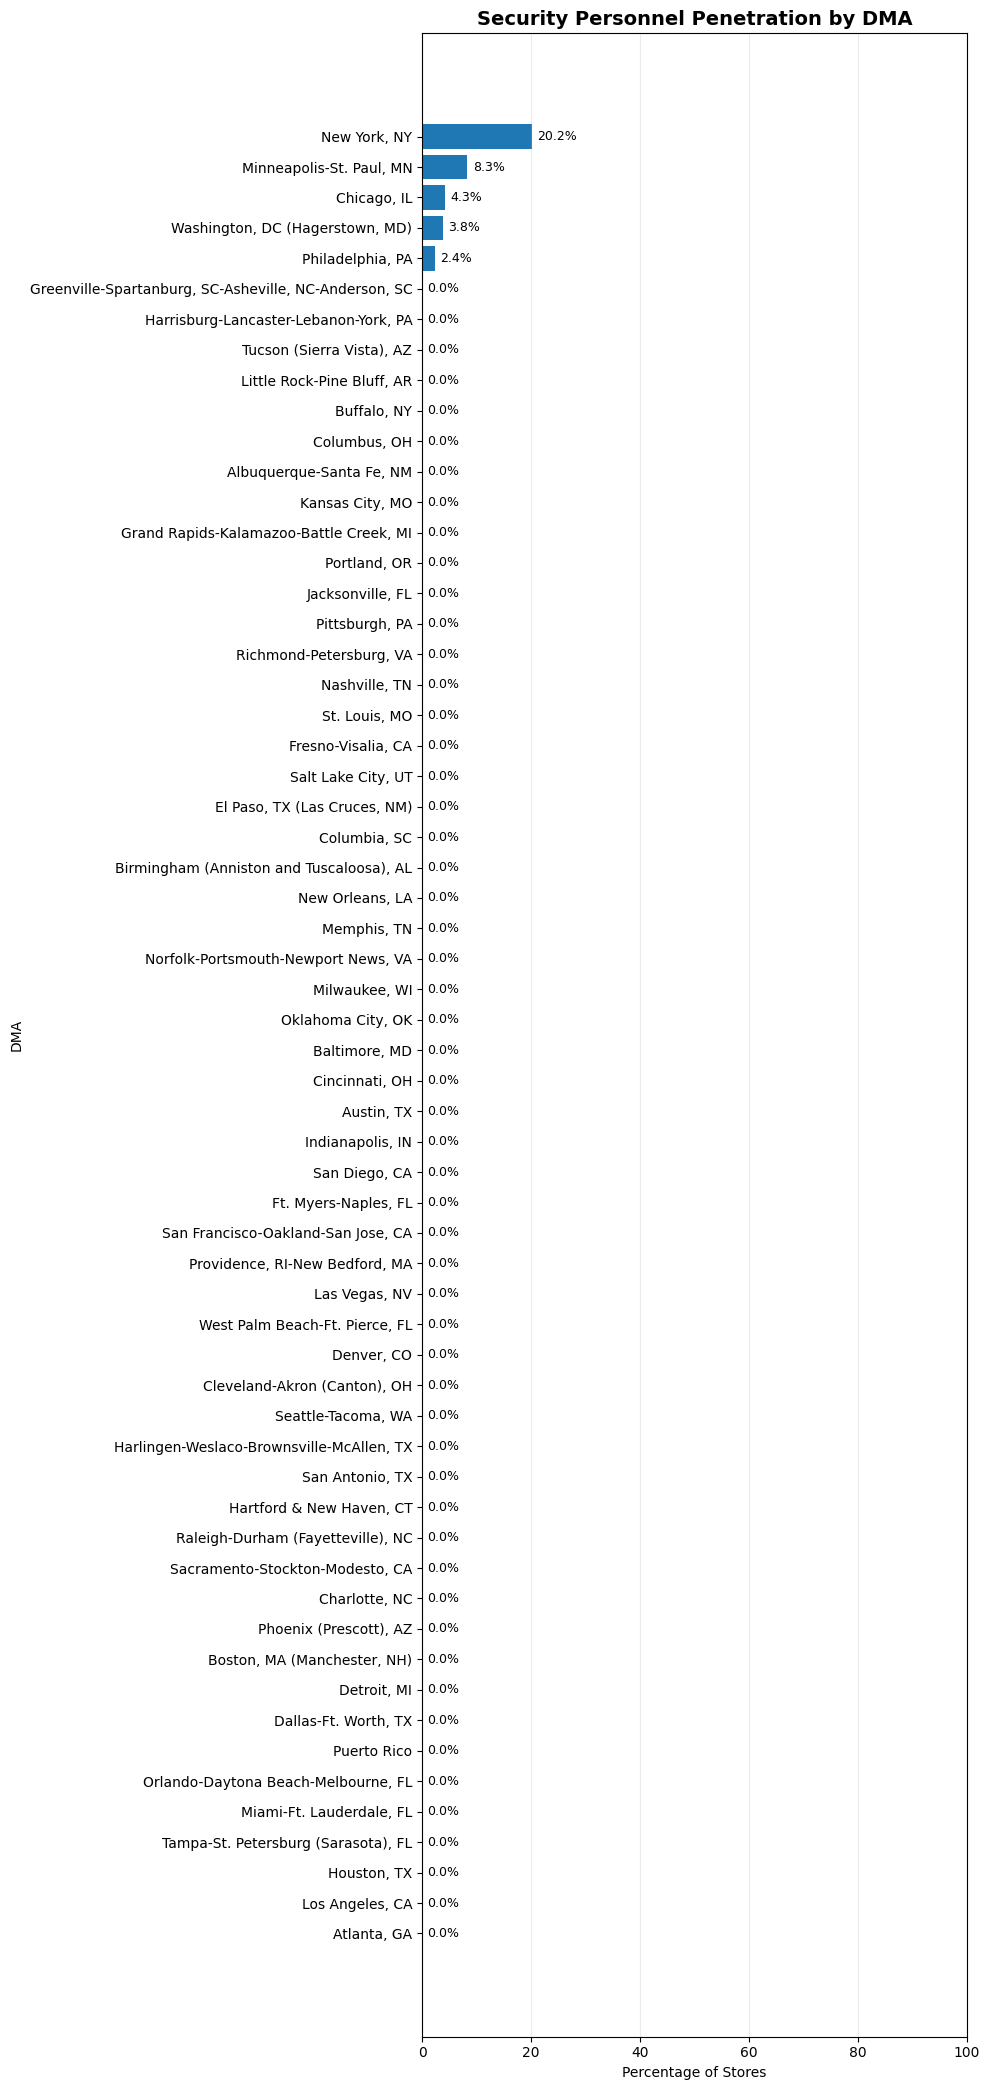

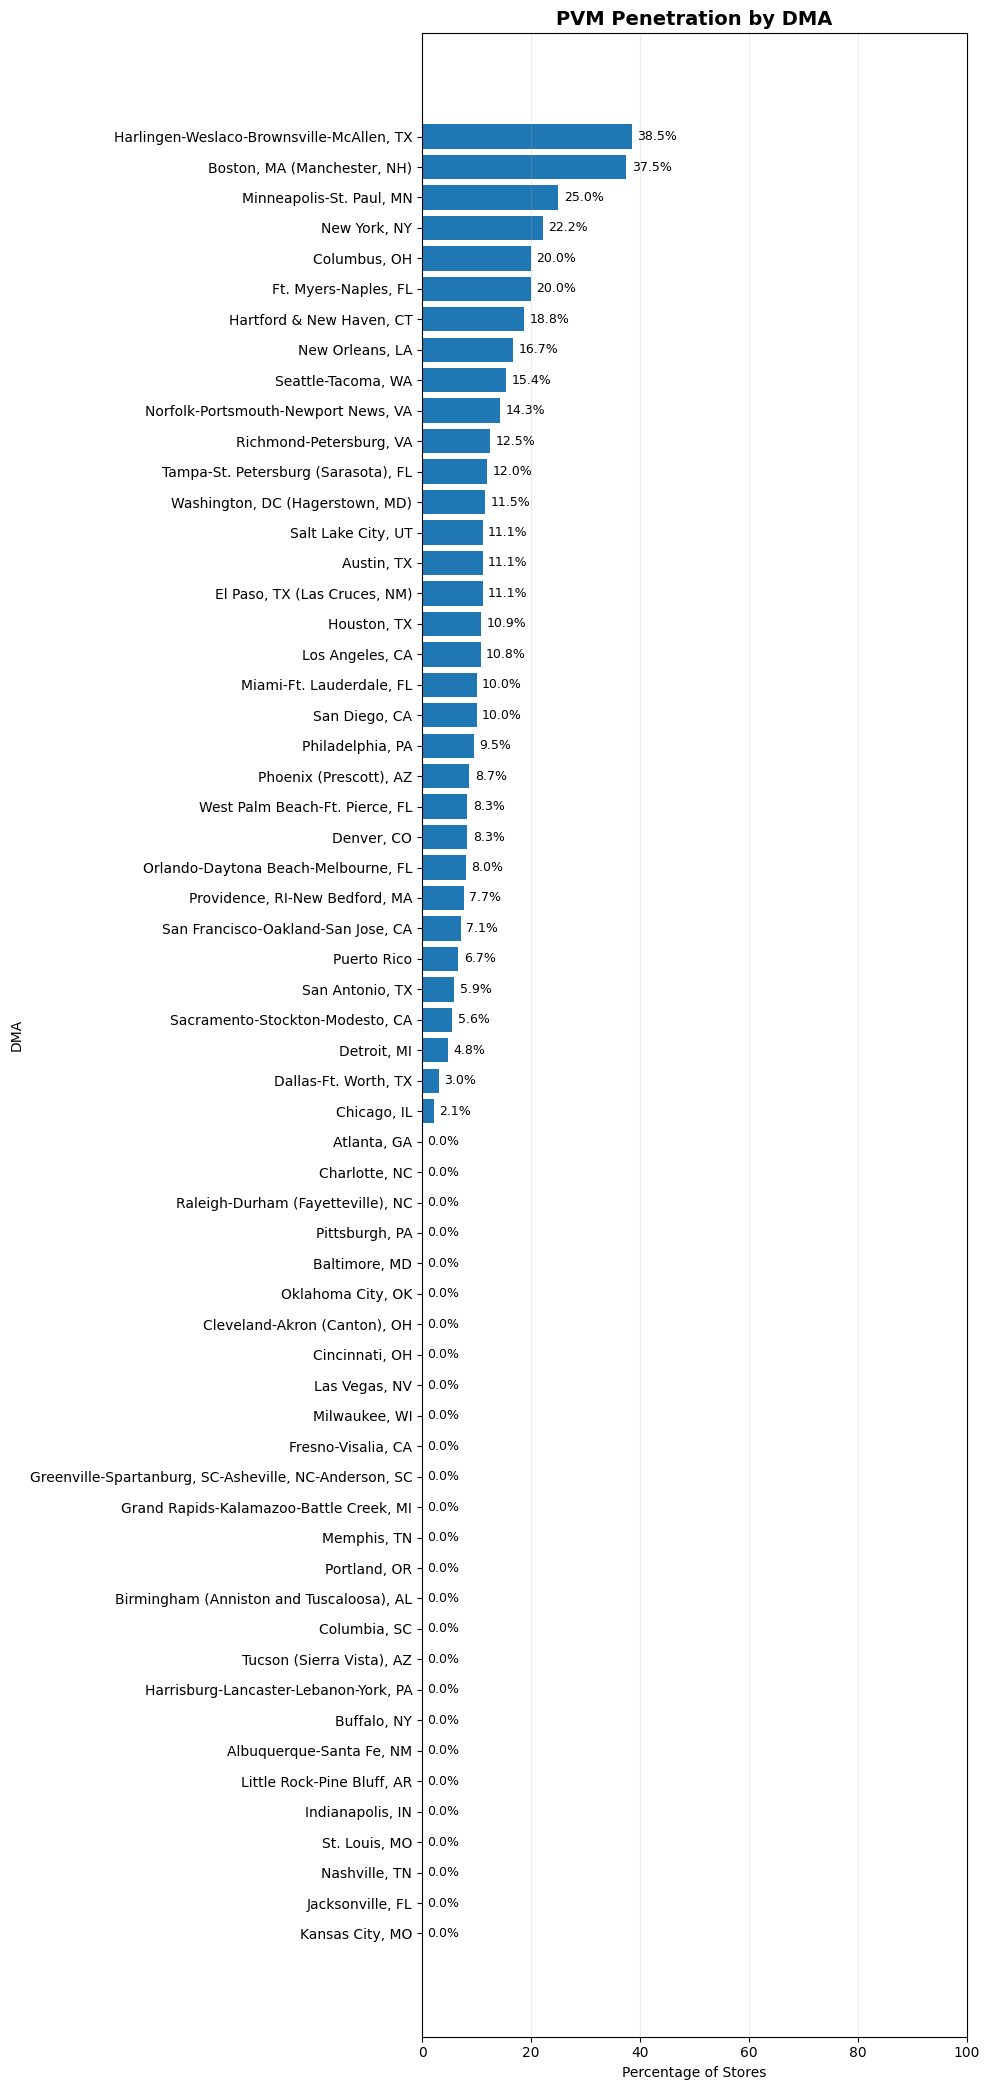

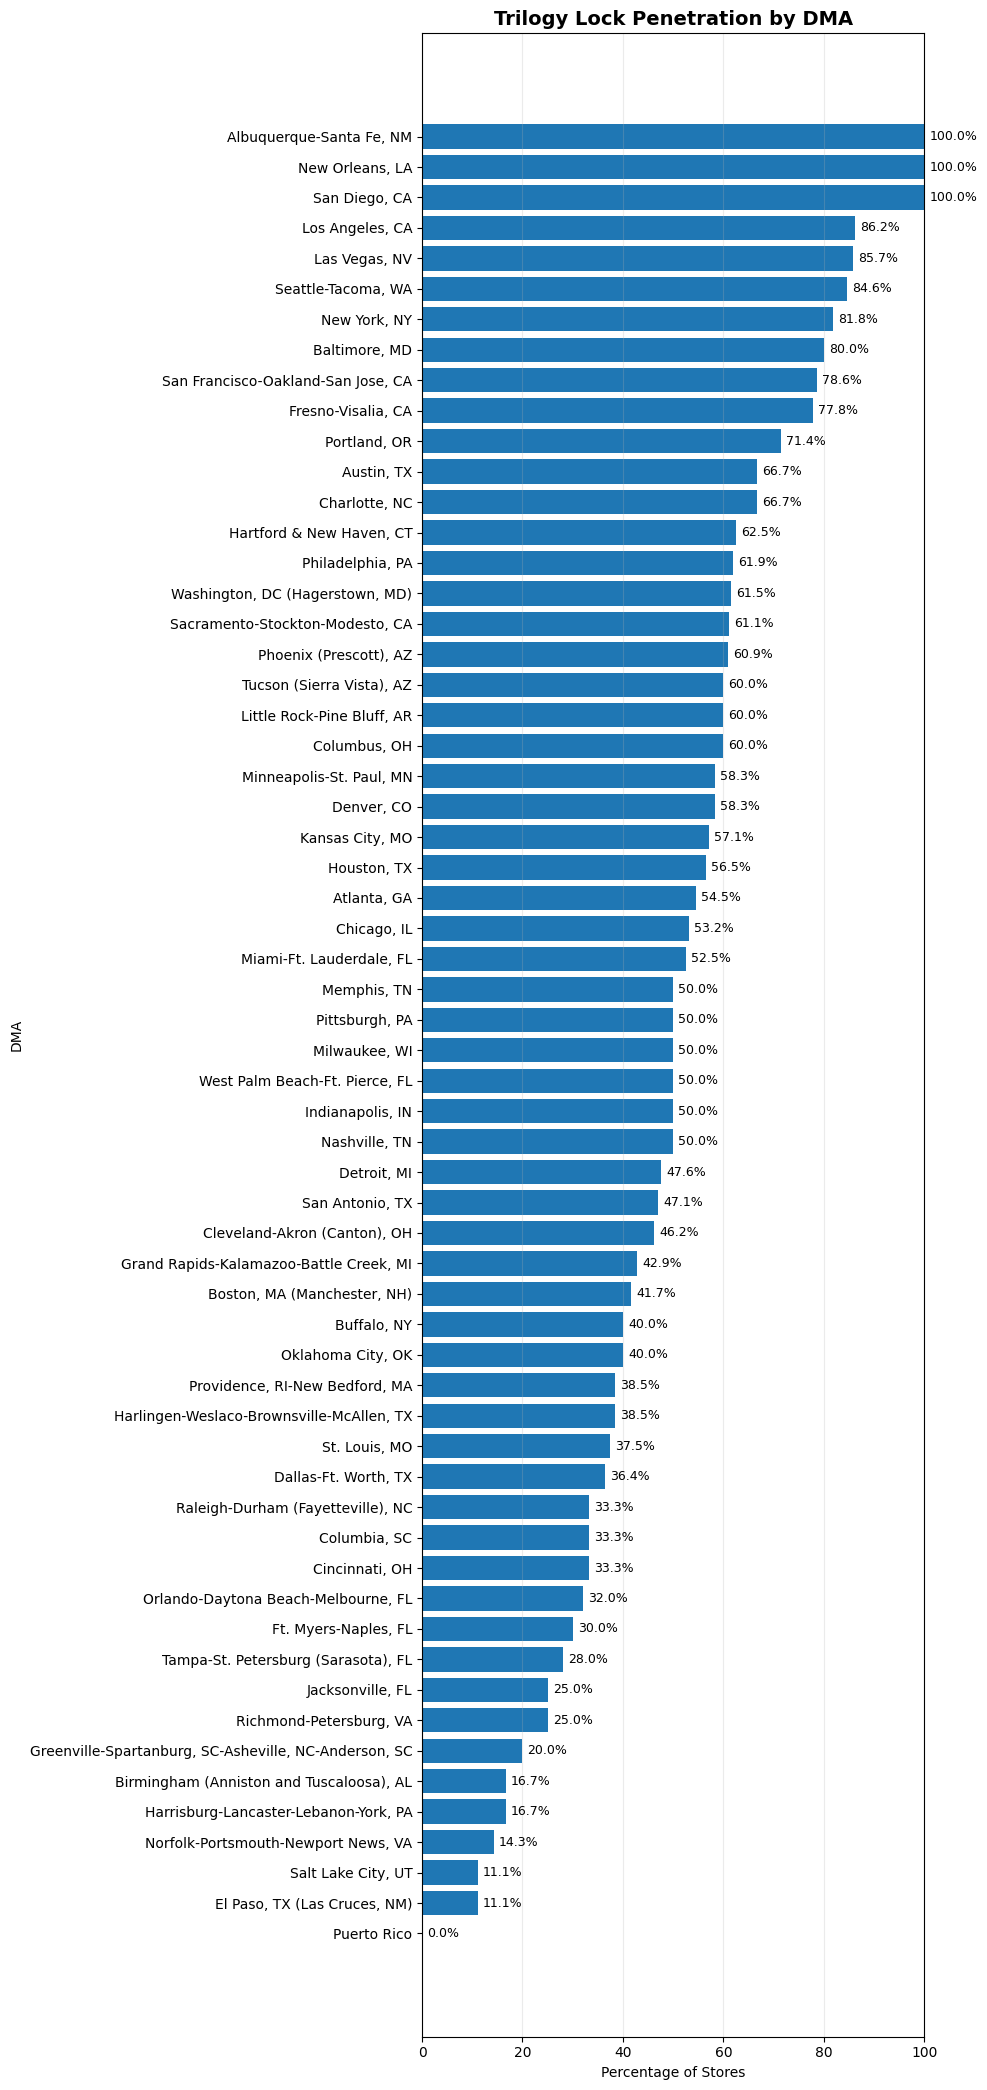

In [20]:
plot_dma_ap_coverage(
    dma_ap_filtered,
    "SCA_Receipt_Pct",
    "SCA Receipt Store Penetration by DMA",
    min_stores=5
)

plot_dma_ap_coverage(
    dma_ap_filtered,
    "Metering_Pct",
    "Metering Store Penetration by DMA",
    min_stores=5
)

plot_dma_ap_coverage(
    dma_ap_filtered,
    "Security_Personnel_Pct",
    "Security Personnel Penetration by DMA",
    min_stores=5
)

plot_dma_ap_coverage(
    dma_ap_filtered,
    "PVM_Pct",
    "PVM Penetration by DMA",
    min_stores=5
)

plot_dma_ap_coverage(
    dma_ap_filtered,
    "Trilogy_Lock_Pct",
    "Trilogy Lock Penetration by DMA",
    min_stores=5
)

In [21]:
# ============================================================
# TOP 5 DMAs BY STORE COUNT
# ============================================================

TOP_N = 5

top_5_dmas = (
    dma_ap_filtered
    .nlargest(TOP_N, "Stores")
    [["DMA", "Stores"]]
    .copy()
)

display(top_5_dmas)

,DMA,Stores
0,"New York, NY",99
1,"Los Angeles, CA",65
2,"Chicago, IL",47
3,"Houston, TX",46
4,"Philadelphia, PA",42


## Cumulative Rollout Analysis

In [22]:
top_5_dma_names = top_5_dmas["DMA"].tolist()

print(top_5_dma_names)

['New York, NY', 'Los Angeles, CA', 'Chicago, IL', 'Houston, TX', 'Philadelphia, PA']


In [23]:
# ============================================================
# TOP 5 DMA STORE-LEVEL ROLLOUT DATA
# ============================================================

top_5_ap = (
    ap.loc[
        ap["DMA"].isin(top_5_dma_names),
        [
            "DMA",
            "Store",
            "SCA_Receipt",
            "SCA Receipt Store (Date of rollout)",
            "Metering",
            "Metering Store (Date of rollout)",
        ]
    ]
    .copy()
)

display(
    top_5_ap
    .sort_values(["DMA", "Store"])
    .head(30)
)

,DMA,Store,SCA_Receipt,SCA Receipt Store (Date of rollout),Metering,Metering Store (Date of rollout)
7,"Chicago, IL",19.0,0,NaT,0,NaT
12,"Chicago, IL",26.0,1,2026-07-13,0,NaT
31,"Chicago, IL",70.0,0,NaT,0,NaT
65,"Chicago, IL",146.0,1,2026-04-03,0,NaT
70,"Chicago, IL",162.0,1,2026-06-29,0,NaT
89,"Chicago, IL",198.0,0,NaT,0,NaT
119,"Chicago, IL",273.0,0,NaT,1,2025-04-07
130,"Chicago, IL",288.0,0,NaT,1,2025-08-16
140,"Chicago, IL",305.0,0,NaT,0,NaT
193,"Chicago, IL",372.0,0,NaT,0,NaT


In [24]:
# ============================================================
# CHECK INDICATOR / DATE CONSISTENCY
# ============================================================

for measure, indicator, date_col in [
    (
        "SCA Receipt",
        "SCA_Receipt",
        "SCA Receipt Store (Date of rollout)"
    ),
    (
        "Metering",
        "Metering",
        "Metering Store (Date of rollout)"
    ),
]:

    print(f"\n{measure}")
    print("-" * 50)

    print(
        "Indicator = 1:",
        top_5_ap[indicator].sum()
    )

    print(
        "Rollout dates present:",
        top_5_ap[date_col].notna().sum()
    )

    print(
        "Indicator = 1 but no rollout date:",
        (
            (top_5_ap[indicator] == 1) &
            (top_5_ap[date_col].isna())
        ).sum()
    )


SCA Receipt
--------------------------------------------------
Indicator = 1: 98
Rollout dates present: 92
Indicator = 1 but no rollout date: 6

Metering
--------------------------------------------------
Indicator = 1: 150
Rollout dates present: 150
Indicator = 1 but no rollout date: 0


In [25]:
# ============================================================
# CREATE MONTHLY ROLLOUT DATES
# ============================================================

top_5_ap["SCA_Rollout_Month"] = (
    top_5_ap["SCA Receipt Store (Date of rollout)"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

top_5_ap["Metering_Rollout_Month"] = (
    top_5_ap["Metering Store (Date of rollout)"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


sca_monthly = (
    top_5_ap
    .dropna(subset=["SCA_Rollout_Month"])
    .groupby(
        ["DMA", "SCA_Rollout_Month"]
    )
    .agg(
        Stores_Implemented=("Store", "nunique")
    )
    .reset_index()
    .rename(columns={
        "SCA_Rollout_Month": "Month"
    })
)

sca_monthly["Measure"] = "SCA Receipt"



metering_monthly = (
    top_5_ap
    .dropna(subset=["Metering_Rollout_Month"])
    .groupby(
        ["DMA", "Metering_Rollout_Month"]
    )
    .agg(
        Stores_Implemented=("Store", "nunique")
    )
    .reset_index()
    .rename(columns={
        "Metering_Rollout_Month": "Month"
    })
)

metering_monthly["Measure"] = "Metering"

rollout_monthly = pd.concat(
    [
        sca_monthly,
        metering_monthly
    ],
    ignore_index=True
)

display(
    rollout_monthly
    .sort_values(["Measure", "DMA", "Month"])
)

,DMA,Month,Stores_Implemented,Measure
31,"Chicago, IL",2024-05-01,6,Metering
32,"Chicago, IL",2025-04-01,4,Metering
33,"Chicago, IL",2025-08-01,3,Metering
34,"Houston, TX",2023-08-01,1,Metering
35,"Houston, TX",2024-05-01,4,Metering
36,"Houston, TX",2024-11-01,1,Metering
37,"Houston, TX",2025-04-01,7,Metering
38,"Houston, TX",2025-08-01,6,Metering
39,"Los Angeles, CA",2023-08-01,8,Metering
40,"Los Angeles, CA",2024-05-01,13,Metering


In [26]:
# ============================================================
# BUILD COMPLETE DMA x MONTH GRID
# ============================================================

min_month = rollout_monthly["Month"].min()
max_month = rollout_monthly["Month"].max()

all_months = pd.date_range(
    start=min_month,
    end=max_month,
    freq="MS"
)

dma_month_grid = pd.MultiIndex.from_product(
    [
        top_5_dma_names,
        all_months,
        ["SCA Receipt", "Metering"]
    ],
    names=["DMA", "Month", "Measure"]
).to_frame(index=False)

rollout_timeline = (
    dma_month_grid
    .merge(
        rollout_monthly,
        on=["DMA", "Month", "Measure"],
        how="left"
    )
)

rollout_timeline["Stores_Implemented"] = (
    rollout_timeline["Stores_Implemented"]
    .fillna(0)
    .astype(int)
)

rollout_timeline = rollout_timeline.sort_values(
    ["DMA", "Measure", "Month"]
)

rollout_timeline["Cumulative_Stores"] = (
    rollout_timeline
    .groupby(["DMA", "Measure"])
    ["Stores_Implemented"]
    .cumsum()
)

rollout_timeline = (
    rollout_timeline
    .merge(
        top_5_dmas,
        on="DMA",
        how="left"
    )
)

rollout_timeline["Cumulative_Pct"] = (
    rollout_timeline["Cumulative_Stores"] /
    rollout_timeline["Stores"]
)

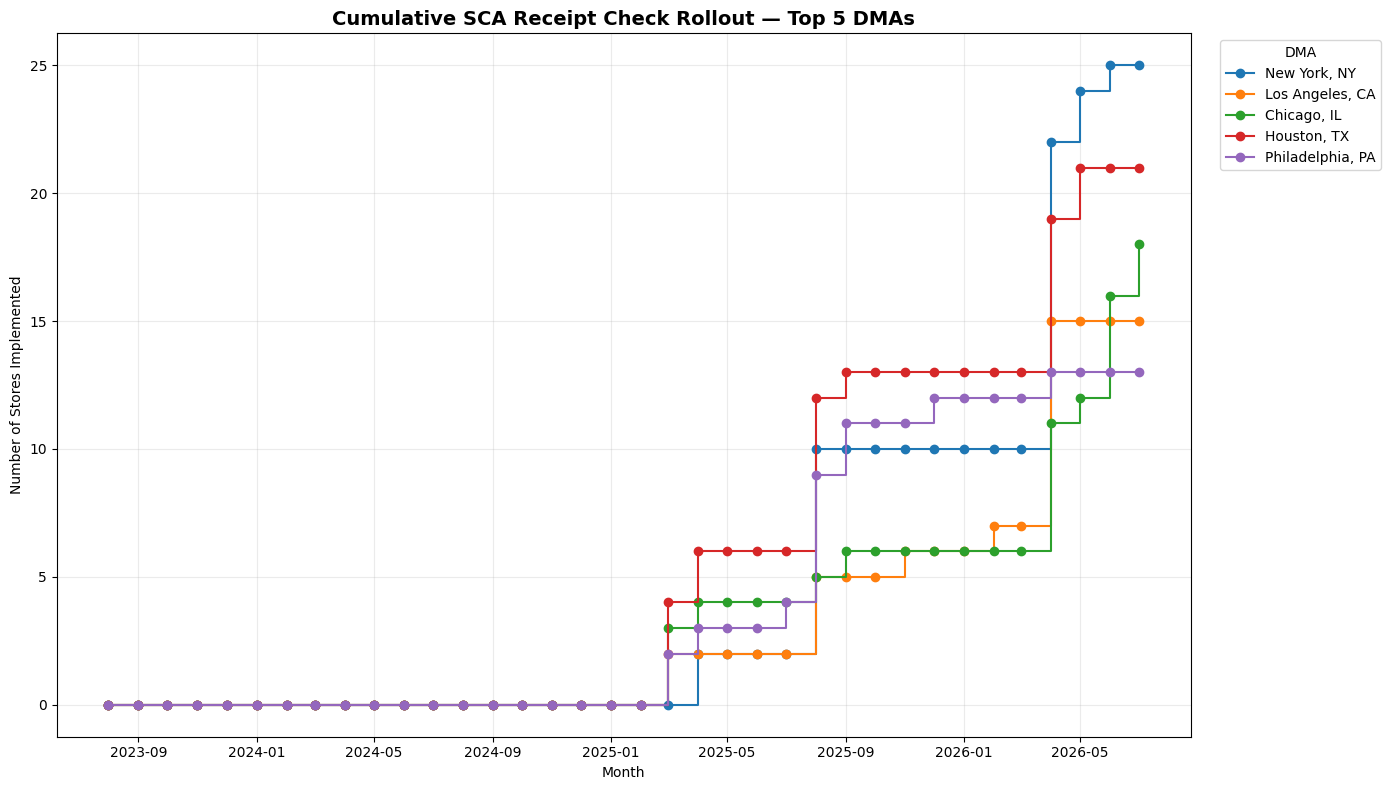

In [27]:
# ============================================================
# CUMULATIVE SCA ROLLOUT - TOP 5 DMAs
# ============================================================

import matplotlib.pyplot as plt

sca_plot = rollout_timeline.loc[
    rollout_timeline["Measure"] == "SCA Receipt"
]

fig, ax = plt.subplots(figsize=(14, 8))

for dma in top_5_dma_names:

    temp = sca_plot.loc[
        sca_plot["DMA"] == dma
    ].sort_values("Month")

    ax.step(
        temp["Month"],
        temp["Cumulative_Stores"],
        where="post",
        marker="o",
        label=dma
    )

ax.set_title(
    "Cumulative SCA Receipt Check Rollout — Top 5 DMAs",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Stores Implemented")

ax.legend(
    title="DMA",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

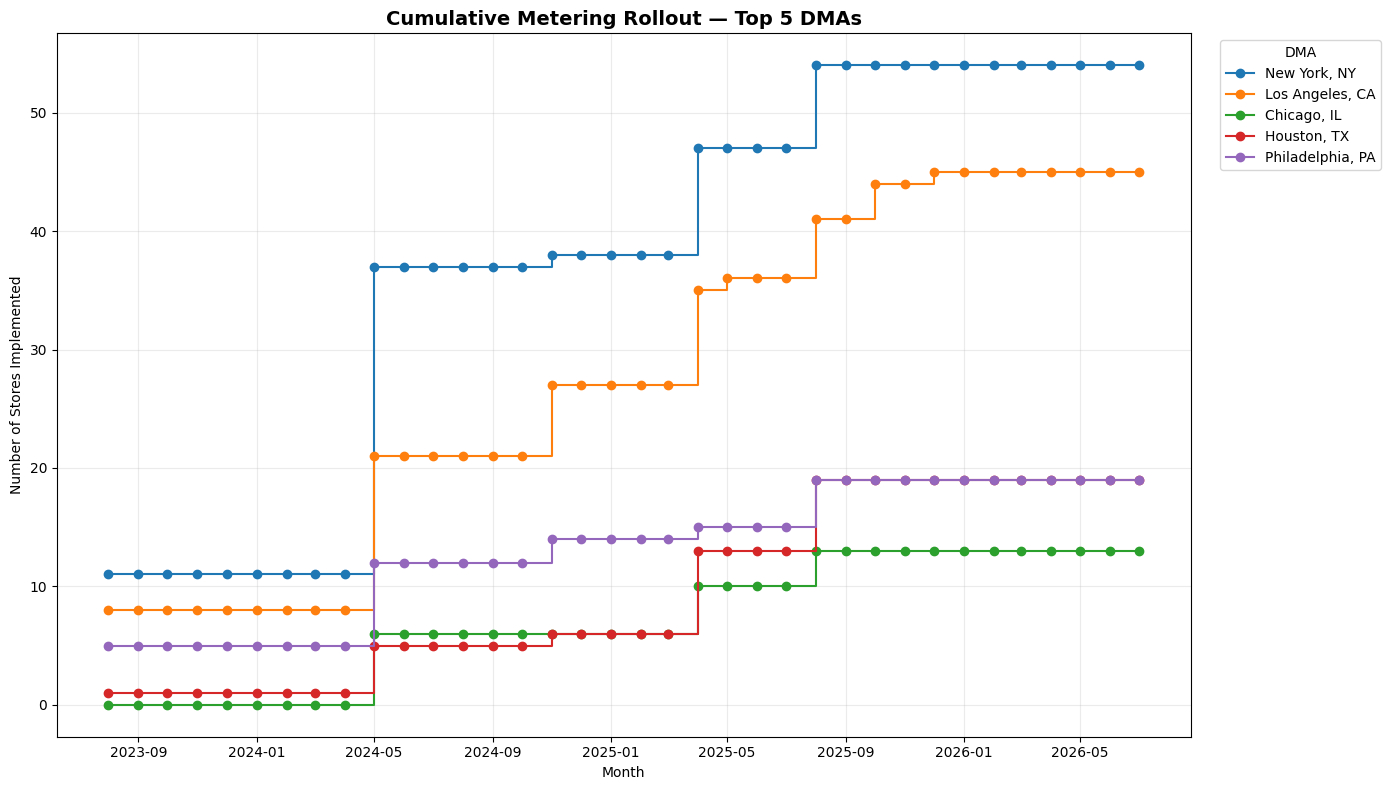

In [28]:
# ============================================================
# CUMULATIVE METERING ROLLOUT - TOP 5 DMAs
# ============================================================

metering_plot = rollout_timeline.loc[
    rollout_timeline["Measure"] == "Metering"
]

fig, ax = plt.subplots(figsize=(14, 8))

for dma in top_5_dma_names:

    temp = metering_plot.loc[
        metering_plot["DMA"] == dma
    ].sort_values("Month")

    ax.step(
        temp["Month"],
        temp["Cumulative_Stores"],
        where="post",
        marker="o",
        label=dma
    )

ax.set_title(
    "Cumulative Metering Rollout — Top 5 DMAs",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Stores Implemented")

ax.legend(
    title="DMA",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

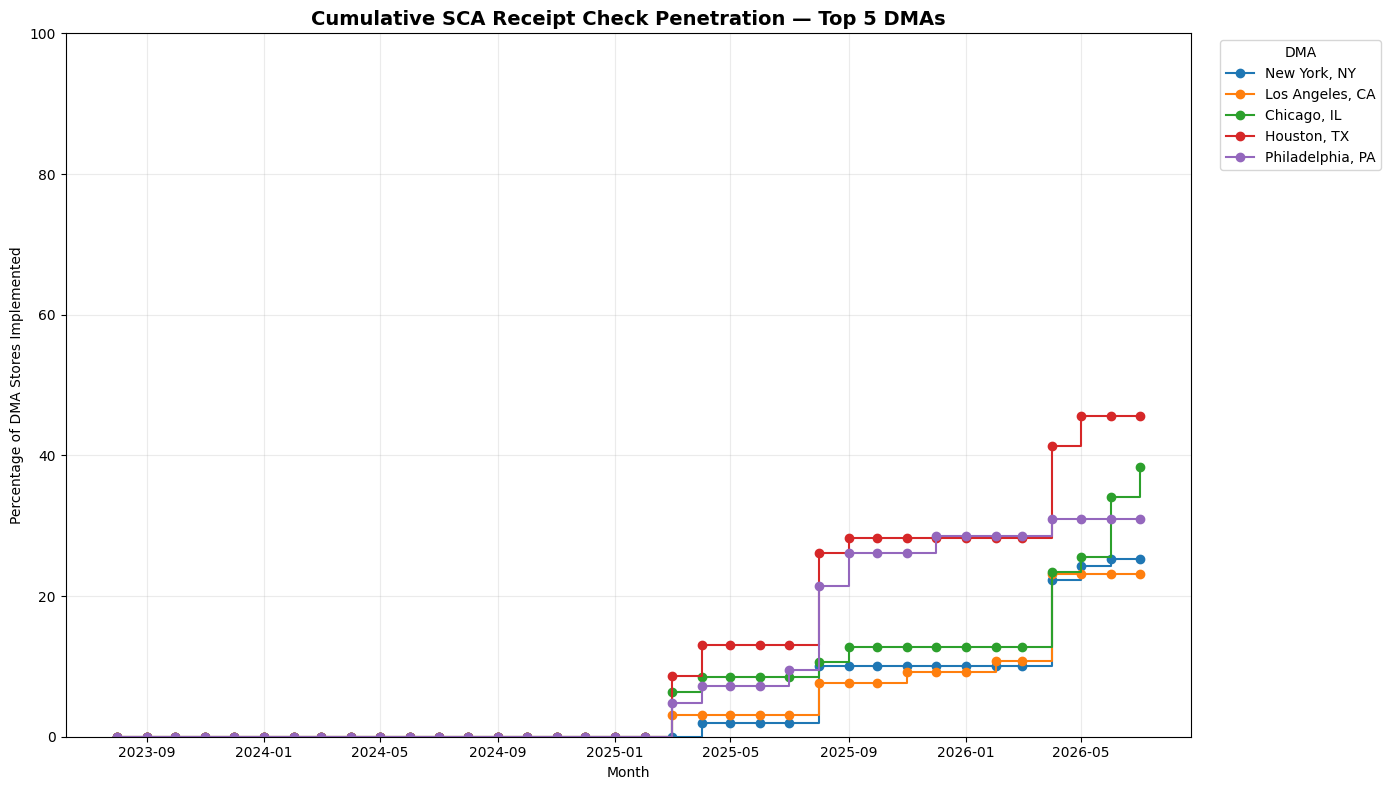

In [29]:
# ============================================================
# CUMULATIVE SCA PENETRATION - TOP 5 DMAs
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

for dma in top_5_dma_names:

    temp = sca_plot.loc[
        sca_plot["DMA"] == dma
    ].sort_values("Month")

    ax.step(
        temp["Month"],
        temp["Cumulative_Pct"] * 100,
        where="post",
        marker="o",
        label=dma
    )

ax.set_title(
    "Cumulative SCA Receipt Check Penetration — Top 5 DMAs",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Percentage of DMA Stores Implemented")
ax.set_ylim(0, 100)

ax.legend(
    title="DMA",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

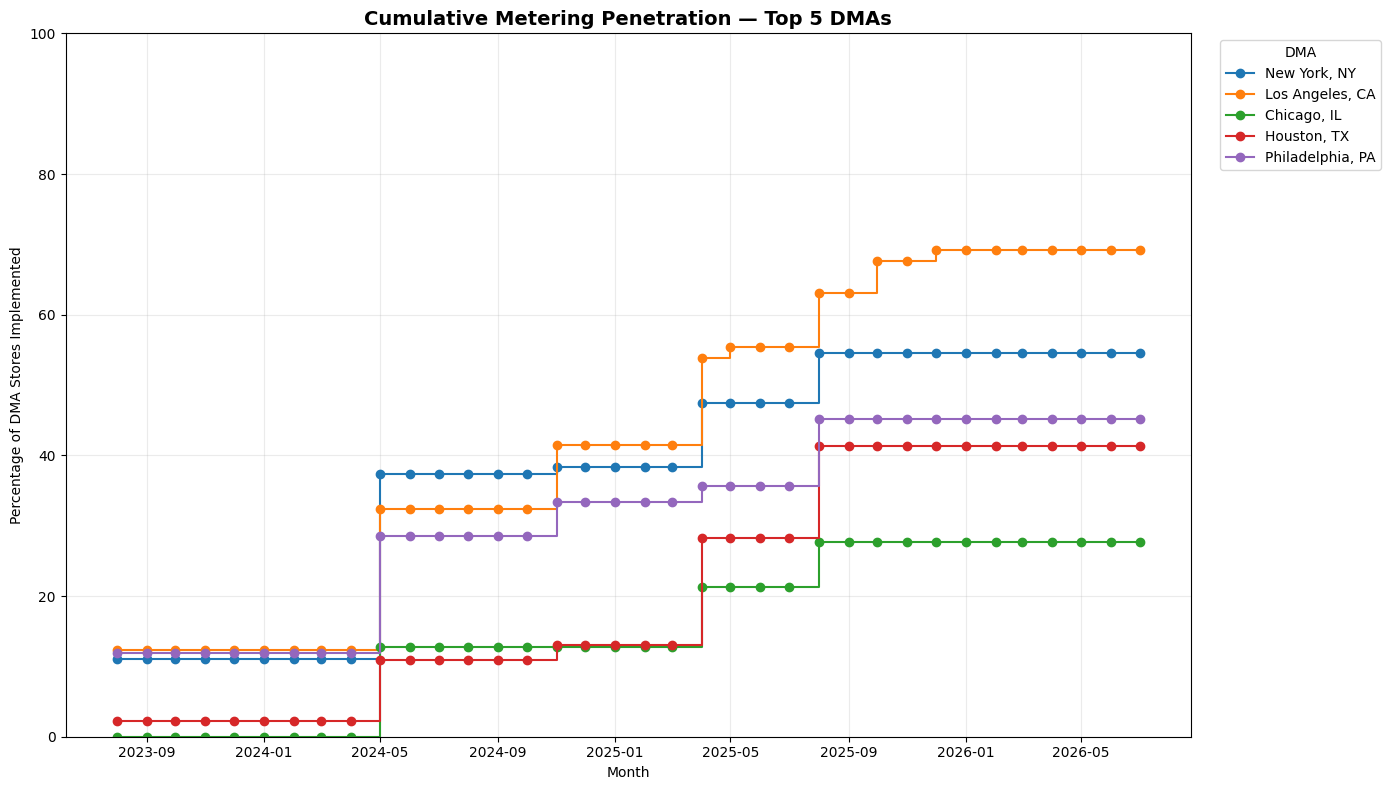

In [30]:
# ============================================================
# CUMULATIVE SCA PENETRATION - TOP 5 DMAs
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

for dma in top_5_dma_names:

    temp = metering_plot.loc[
        metering_plot["DMA"] == dma
    ].sort_values("Month")

    ax.step(
        temp["Month"],
        temp["Cumulative_Pct"] * 100,
        where="post",
        marker="o",
        label=dma
    )

ax.set_title(
    "Cumulative Metering Penetration — Top 5 DMAs",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Percentage of DMA Stores Implemented")
ax.set_ylim(0, 100)

ax.legend(
    title="DMA",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Connecting AP Measures to Traffic


In [31]:
traffic = pd.read_csv('/content/traffic.csv')

print(traffic.head())
print(traffic.columns.to_list())

   Store       Location Month  Year WeekEndDate  Exits   Exits LY   \
0      2  MILWAUKEE, WI   FEB  2026    2/7/2026   4,651      4,267   
1      2  MILWAUKEE, WI   FEB  2026   2/14/2026   4,151      4,038   
2      2  MILWAUKEE, WI   FEB  2026   2/21/2026   4,511      4,456   
3      2  MILWAUKEE, WI   FEB  2026   2/28/2026   3,319      3,477   
4      2  MILWAUKEE, WI   MAR  2026    3/7/2026   5,463      5,203   

  # Sale Txns # Sale Txns LY  
0       2,466          2,362  
1       2,247          2,262  
2       2,383          2,410  
3       1,688          1,850  
4       2,853          2,829  
['Store', 'Location', 'Month', 'Year', 'WeekEndDate', ' Exits ', ' Exits LY ', '# Sale Txns', '# Sale Txns LY']


/tmp/ipykernel_820/4073580535.py:1: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  traffic = pd.read_csv('/content/traffic.csv')


In [32]:
# ============================================================
# 1. CLEAN TRAFFIC DATA
# ============================================================

traffic = traffic.copy()

traffic["WeekEndDate"] = pd.to_datetime(
    traffic["WeekEndDate"],
    errors="coerce"
)

numeric_cols = [
    " Exits ",
    " Exits LY ",
    "# Sale Txns",
    "# Sale Txns LY",
]

for col in numeric_cols:
    traffic[col] = (
        traffic[col]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip()
        .pipe(pd.to_numeric, errors="coerce")
    )

# Cleaner names
traffic = traffic.rename(columns={
    " Exits ": "Exits",
    " Exits LY ": "Exits_LY",
    "# Sale Txns": "Sale_Txns",
    "# Sale Txns LY": "Sale_Txns_LY",
})

# Month based on actual week-ending date
traffic["Date"] = (
    traffic["WeekEndDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(traffic.dtypes)

display(traffic.head())



# ============================================================
# 2. AGGREGATE WEEKLY TRAFFIC TO STORE-MONTH
# ============================================================

store_month_traffic = (
    traffic
    .dropna(subset=["Store", "Date"])
    .groupby(
        ["Store", "Date"],
        as_index=False
    )
    .agg(
        Exits=("Exits", "sum"),
        Exits_LY=("Exits_LY", "sum"),
        Sale_Txns=("Sale_Txns", "sum"),
        Sale_Txns_LY=("Sale_Txns_LY", "sum"),
        Weeks=("WeekEndDate", "nunique"),
    )
)

display(store_month_traffic.head())


Store                    int64
Location                object
Month                   object
Year                     int64
WeekEndDate     datetime64[ns]
Exits                    Int64
Exits_LY                 Int64
Sale_Txns              Float64
Sale_Txns_LY             Int64
Date            datetime64[ns]
dtype: object


,Store,Location,Month,Year,WeekEndDate,Exits,Exits_LY,Sale_Txns,Sale_Txns_LY,Date
0,2,"MILWAUKEE, WI",FEB,2026,2026-02-07,4651,4267,2466.0,2362,2026-02-01
1,2,"MILWAUKEE, WI",FEB,2026,2026-02-14,4151,4038,2247.0,2262,2026-02-01
2,2,"MILWAUKEE, WI",FEB,2026,2026-02-21,4511,4456,2383.0,2410,2026-02-01
3,2,"MILWAUKEE, WI",FEB,2026,2026-02-28,3319,3477,1688.0,1850,2026-02-01
4,2,"MILWAUKEE, WI",MAR,2026,2026-03-07,5463,5203,2853.0,2829,2026-03-01


,Store,Date,Exits,Exits_LY,Sale_Txns,Sale_Txns_LY,Weeks
0,2,2024-02-01,14548,16581,7671.0,8163,3
1,2,2024-03-01,24903,25981,13231.0,13495,5
2,2,2024-04-01,21628,25170,11427.0,13012,4
3,2,2024-05-01,22561,23898,12029.0,12640,4
4,2,2024-06-01,30881,35110,16239.0,17954,5


In [33]:
# ============================================================
# 3. PREPARE STORE-LEVEL AP DATA
# ============================================================

ap_store = (
    ap[
        [
            "Store",
            "DMA",
            "SCA_Receipt",
            "SCA Receipt Store (Date of rollout)",
            "Metering",
            "Metering Store (Date of rollout)",
        ]
    ]
    .copy()
)

ap_store = ap_store.rename(columns={
    "SCA Receipt Store (Date of rollout)": "SCA_Rollout_Date",
    "Metering Store (Date of rollout)": "Metering_Rollout_Date",
})

ap_store["SCA_Rollout_Date"] = pd.to_datetime(
    ap_store["SCA_Rollout_Date"],
    errors="coerce"
)

ap_store["Metering_Rollout_Date"] = pd.to_datetime(
    ap_store["Metering_Rollout_Date"],
    errors="coerce"
)


print(f"AP rows: {len(ap_store):,}")
print(f"Unique stores: {ap_store['Store'].nunique():,}")
print(
    f"Duplicate Store IDs: "
    f"{ap_store['Store'].duplicated().sum():,}"
)

AP rows: 1,362
Unique stores: 1,334
Duplicate Store IDs: 27


In [34]:
ap_store=ap_store.drop_duplicates()

print(f"AP rows: {len(ap_store):,}")
print(f"Unique stores: {ap_store['Store'].nunique():,}")
print(
    f"Duplicate Store IDs: "
    f"{ap_store['Store'].duplicated().sum():,}"
)

AP rows: 1,335
Unique stores: 1,334
Duplicate Store IDs: 0


In [35]:
ap_store = ap_store.dropna(subset=["Store"]).copy()

ap_store["Store"] = ap_store["Store"].astype(int)
store_month_traffic["Store"] = store_month_traffic["Store"].astype(int)

print("Traffic Store dtype:", store_month_traffic["Store"].dtype)
print("AP Store dtype:", ap_store["Store"].dtype)

Traffic Store dtype: int64
AP Store dtype: int64


In [36]:
# ============================================================
# 4. MERGE TRAFFIC + AP
# ============================================================

store_month_panel = (
    store_month_traffic
    .merge(
        ap_store,
        on="Store",
        how="left",
        validate="many_to_one"
    )
)

print(f"Store-month rows: {len(store_month_panel):,}")

print(
    "Rows with DMA:",
    store_month_panel["DMA"].notna().sum()
)

print(
    "Rows missing DMA:",
    store_month_panel["DMA"].isna().sum()
)

display(store_month_panel.head())

Store-month rows: 25,770
Rows with DMA: 25607
Rows missing DMA: 163


,Store,Date,Exits,Exits_LY,Sale_Txns,Sale_Txns_LY,Weeks,DMA,SCA_Receipt,SCA_Rollout_Date,Metering,Metering_Rollout_Date
0,2,2024-02-01,14548,16581,7671.0,8163,3,"Milwaukee, WI",1.0,2026-04-03,0.0,NaT
1,2,2024-03-01,24903,25981,13231.0,13495,5,"Milwaukee, WI",1.0,2026-04-03,0.0,NaT
2,2,2024-04-01,21628,25170,11427.0,13012,4,"Milwaukee, WI",1.0,2026-04-03,0.0,NaT
3,2,2024-05-01,22561,23898,12029.0,12640,4,"Milwaukee, WI",1.0,2026-04-03,0.0,NaT
4,2,2024-06-01,30881,35110,16239.0,17954,5,"Milwaukee, WI",1.0,2026-04-03,0.0,NaT


In [60]:
# ============================================================
# DIAGNOSE TRAFFIC COMP OUTLIERS
# ============================================================

print(
    store_month_panel["Traffic_Comp"]
    .describe(
        percentiles=[
            .001,
            .005,
            .01,
            .025,
            .05,
            .25,
            .50,
            .75,
            .95,
            .975,
            .99,
            .995,
            .999
        ]
    )
)

count    25381.0
mean        <NA>
std         <NA>
min         <NA>
0.1%        <NA>
0.5%        <NA>
1%          <NA>
2.5%        <NA>
5%          <NA>
25%         <NA>
50%         <NA>
75%         <NA>
95%         <NA>
97.5%       <NA>
99%         <NA>
99.5%       <NA>
99.9%       <NA>
max         <NA>
Name: Traffic_Comp, dtype: Float64


In [62]:
# Identifying extreme outliers

extreme_traffic = (
    store_month_panel[
        [
            "Store",
            "DMA",
            "Date",
            "Exits",
            "Exits_LY",
            "Traffic_Comp",
            "SCA_Rollout_Date",
        ]
    ]
    .dropna(subset=["Traffic_Comp"])
    .assign(
        Abs_Traffic_Comp=lambda x:
            x["Traffic_Comp"].abs()
    )
    .sort_values(
        "Abs_Traffic_Comp",
        ascending=False
    )
)

display(extreme_traffic.head(30))

,Store,DMA,Date,Exits,Exits_LY,Traffic_Comp,SCA_Rollout_Date,Abs_Traffic_Comp
11729,1013,"Houston, TX",2025-11-01,0,0,NaN,2025-03-24,NaN
7910,753,"Chicago, IL",2026-04-01,1218,1,1217.0,2026-04-03,1217.0
7109,572,"Louisville, KY",2026-04-01,1939,2,968.5,NaT,968.5
5435,456,"Dallas-Ft. Worth, TX",2026-04-01,2340,3,779.0,NaT,779.0
2254,226,"Philadelphia, PA",2025-04-01,1210,2,604.0,NaT,604.0
5456,457,"New York, NY",2025-12-01,4489,9,497.777778,2026-05-15,497.777778
24227,1495,"Joplin, MO-Pittsburg, KS",2026-04-01,288,1,287.0,NaT,287.0
5457,457,"New York, NY",2026-04-01,2431,9,269.111111,2026-05-15,269.111111
5810,486,"El Paso, TX (Las Cruces, NM)",2024-04-01,2875,45,62.888889,2026-04-03,62.888889
3856,347,"Tampa-St. Petersburg (Sarasota), FL",2025-04-01,2425,63,37.492063,2026-04-03,37.492063


In [65]:
display(
    sca_event_norm.loc[
        sca_event_norm["Event_Month"].isin(
            [-5, 0, 1, 2, 3]
        ),
        [
            "Store",
            "DMA",
            "Event_Month",
            "Exits",
            "Exits_LY",
            "Traffic_Comp",
            "Baseline_Traffic_Comp",
            "Traffic_Comp_Change",
        ]
    ]
    .assign(
        Abs_Change=lambda x:
            x["Traffic_Comp_Change"].abs()
    )
    .sort_values(
        "Abs_Change",
        ascending=False
    )
    .head(30)
)

,Store,DMA,Event_Month,Exits,Exits_LY,Traffic_Comp,Baseline_Traffic_Comp,Traffic_Comp_Change,Abs_Change
1019,753,"Chicago, IL",0,1218,1,1217.0,0.084581,1216.915419,1216.915419
682,457,"New York, NY",2,63200,67073,-0.057743,269.111111,-269.168854,269.168854
683,457,"New York, NY",3,54339,56544,-0.038996,269.111111,-269.150107,269.150107
681,457,"New York, NY",1,20211,19310,0.04666,269.111111,-269.064451,269.064451
679,457,"New York, NY",-5,4489,9,497.777778,269.111111,228.666667,228.666667
1689,1069,"Los Angeles, CA",-5,9,4,1.25,-0.034287,1.284287,1.284287
273,179,"San Francisco-Oakland-San Jose, CA",0,176,1496,-0.882353,0.034609,-0.916962,0.916962
1865,1123,"Tampa-St. Petersburg (Sarasota), FL",-5,108,278,-0.611511,0.011816,-0.623326,0.623326
525,347,"Tampa-St. Petersburg (Sarasota), FL",-5,16,34,-0.529412,0.015773,-0.545185,0.545185
1882,1128,"Boston, MA (Manchester, NH)",2,56358,64252,-0.12286,0.224516,-0.347376,0.347376


In [64]:
display(
    store_month_panel
    .groupby("Weeks")
    .agg(
        Observations=("Store", "size"),
        Median_Exits=("Exits", "median"),
        Median_Exits_LY=("Exits_LY", "median"),
        Median_Traffic_Comp=("Traffic_Comp", "median"),
        Mean_Traffic_Comp=("Traffic_Comp", "mean"),
    )
)

,Observations,Median_Exits,Median_Exits_LY,Median_Traffic_Comp,Mean_Traffic_Comp
Weeks,,,,,
1,864,1389.0,472.0,-0.044838,NaN
2,534,7242.0,7580.0,-0.022585,0.027507
3,2229,17391.0,17569.0,-0.011209,-0.011722
4,14852,24784.0,24705.0,0.00083,0.001074
5,7291,32610.0,32405.0,0.00527,0.006618


In [66]:
# Evaluating Exits LY

# ============================================================
# EXITS LY DISTRIBUTION
# ============================================================

print(
    store_month_panel["Exits_LY"]
    .describe(
        percentiles=[
            .001,
            .005,
            .01,
            .025,
            .05,
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)

count         25770.0
mean     29360.807451
std      19219.976902
min               0.0
0.1%              0.0
0.5%              0.0
1%                0.0
2.5%           1558.9
5%            6967.45
10%           12296.0
25%          18045.25
50%           25307.5
75%           35920.0
90%           50963.7
95%           63628.1
99%         101255.62
max          243751.0
Name: Exits_LY, dtype: Float64


In [67]:
# ============================================================
# TRAFFIC COMP SENSITIVITY TO LY THRESHOLD
# ============================================================

thresholds = [0, 100, 250, 500, 1000, 2000]

results = []

for threshold in thresholds:

    temp = store_month_panel.loc[
        store_month_panel["Exits_LY"] >= threshold
    ]

    results.append({
        "Min_Exits_LY": threshold,
        "Observations": len(temp),
        "Stores": temp["Store"].nunique(),
        "Median_Traffic_Comp": temp["Traffic_Comp"].median(),
        "Mean_Traffic_Comp": temp["Traffic_Comp"].mean(),
        "P01": temp["Traffic_Comp"].quantile(.01),
        "P99": temp["Traffic_Comp"].quantile(.99),
    })

ly_threshold_summary = pd.DataFrame(results)

display(
    ly_threshold_summary.style.format({
        "Median_Traffic_Comp": "{:.2%}",
        "Mean_Traffic_Comp": "{:.2%}",
        "P01": "{:.2%}",
        "P99": "{:.2%}",
    })
)

,Min_Exits_LY,Observations,Stores,Median_Traffic_Comp,Mean_Traffic_Comp,P01,P99
0,0,25770,1095,0.06%,,nan%,nan%
1,100,25358,1081,0.06%,0.01%,-24.90%,24.92%
2,250,25355,1081,0.06%,-0.04%,-24.90%,24.89%
3,500,25333,1081,0.06%,-0.06%,-24.65%,24.61%
4,1000,25219,1078,0.06%,-0.09%,-23.85%,23.84%
5,2000,25064,1068,0.07%,0.02%,-22.57%,23.24%


In [70]:
# Defining min exits

MIN_EXITS_LY = 500

# ============================================================
# VALID TRAFFIC OBSERVATIONS
# ============================================================

store_month_panel["Valid_Traffic_Comp"] = (
    store_month_panel["Exits_LY"].ge(MIN_EXITS_LY)
    &
    store_month_panel["Traffic_Comp"].notna()
)

traffic_analysis_panel = (
    store_month_panel.loc[
        store_month_panel["Valid_Traffic_Comp"]
    ]
    .copy()
)

store_month_panel["Low_LY_Base"] = (
    store_month_panel["Exits_LY"] < MIN_EXITS_LY
)

store_month_panel["Traffic_Comp_Eligible"] = (
    store_month_panel["Exits_LY"] >= MIN_EXITS_LY
)


print(
    "Total store-month observations:",
    f"{len(store_month_panel):,}"
)

print(
    "Traffic-comp eligible:",
    f"{store_month_panel['Traffic_Comp_Eligible'].sum():,}"
)

print(
    "Excluded for low LY base:",
    f"{store_month_panel['Low_LY_Base'].sum():,}"
)

print(
    "Percent retained:",
    f"{store_month_panel['Traffic_Comp_Eligible'].mean():.1%}"
)


Total store-month observations: 25,770
Traffic-comp eligible: 25,333
Excluded for low LY base: 437
Percent retained: 98.3%


In [72]:
# ============================================================
# 5. CREATE TIME-VARYING AP TREATMENT VARIABLES
# ============================================================

store_month_panel["SCA_Active"] = (
    store_month_panel["SCA_Rollout_Date"].notna()
    &
    (
        store_month_panel["Date"] >=
        store_month_panel["SCA_Rollout_Date"]
            .dt.to_period("M")
            .dt.to_timestamp()
    )
).astype(int)


store_month_panel["Metering_Active"] = (
    store_month_panel["Metering_Rollout_Date"].notna()
    &
    (
        store_month_panel["Date"] >=
        store_month_panel["Metering_Rollout_Date"]
            .dt.to_period("M")
            .dt.to_timestamp()
    )
).astype(int)

In [73]:
# ============================================================
# 6. STORE-MONTH TRAFFIC METRICS
# ============================================================

store_month_panel["Traffic_Comp"] = (
    store_month_panel["Exits"] /
    store_month_panel["Exits_LY"]
) - 1

store_month_panel["Txn_Comp"] = (
    store_month_panel["Sale_Txns"] /
    store_month_panel["Sale_Txns_LY"]
) - 1


store_month_panel[
    ["Traffic_Comp", "Txn_Comp"]
] = (
    store_month_panel[
        ["Traffic_Comp", "Txn_Comp"]
    ]
    .replace([np.inf, -np.inf], np.nan)
)

In [74]:
# ============================================================
# 7. BUILD DMA-MONTH PANEL
# ============================================================

dma_month_panel = (
    store_month_panel
    .dropna(subset=["DMA"])
    .groupby(
        ["DMA", "Date"],
        as_index=False
    )
    .agg(
        Stores=("Store", "nunique"),

        Exits=("Exits", "sum"),
        Exits_LY=("Exits_LY", "sum"),

        Sale_Txns=("Sale_Txns", "sum"),
        Sale_Txns_LY=("Sale_Txns_LY", "sum"),

        SCA_Stores=("SCA_Active", "sum"),
        Metering_Stores=("Metering_Active", "sum"),
    )
)

In [75]:
dma_month_panel["Traffic_Comp"] = (
    dma_month_panel["Exits"] /
    dma_month_panel["Exits_LY"]
) - 1

dma_month_panel["Txn_Comp"] = (
    dma_month_panel["Sale_Txns"] /
    dma_month_panel["Sale_Txns_LY"]
) - 1


dma_month_panel["SCA_Pct"] = (
    dma_month_panel["SCA_Stores"] /
    dma_month_panel["Stores"]
)

dma_month_panel["Metering_Pct"] = (
    dma_month_panel["Metering_Stores"] /
    dma_month_panel["Stores"]
)

dma_month_panel.head()

,DMA,Date,Stores,Exits,Exits_LY,Sale_Txns,Sale_Txns_LY,SCA_Stores,Metering_Stores,Traffic_Comp,Txn_Comp,SCA_Pct,Metering_Pct
0,"Abilene-Sweetwater, TX",2024-02-01,1,17523,16591,8197.0,7652,0,0,0.056175,0.071223,0.0,0.0
1,"Abilene-Sweetwater, TX",2024-03-01,1,32190,29177,14856.0,13267,0,0,0.103266,0.119771,0.0,0.0
2,"Abilene-Sweetwater, TX",2024-04-01,1,22731,22508,11041.0,10578,0,0,0.009908,0.04377,0.0,0.0
3,"Abilene-Sweetwater, TX",2024-05-01,1,24979,22997,12225.0,10997,0,0,0.086185,0.111667,0.0,0.0
4,"Abilene-Sweetwater, TX",2024-06-01,1,32080,29505,14721.0,13792,0,0,0.087273,0.067358,0.0,0.0


In [76]:
# ============================================================
# TOP 5 DMAs FOR TRAFFIC / AP ANALYSIS
# ============================================================

TOP_N = 5

top_5_dmas = (
    dma_ap_filtered
    .nlargest(TOP_N, "Stores")
    ["DMA"]
    .tolist()
)

print(top_5_dmas)


['New York, NY', 'Los Angeles, CA', 'Chicago, IL', 'Houston, TX', 'Philadelphia, PA']


In [77]:
# ============================================================
# DMA TRAFFIC + AP PENETRATION PLOT
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


def plot_dma_traffic_ap(
    df,
    dma,
    ap_col,
    ap_label
):

    temp = (
        df.loc[df["DMA"] == dma]
        .sort_values("Date")
        .copy()
    )

    fig, ax1 = plt.subplots(figsize=(13, 6))

    # -------------------------
    # Traffic Comp
    # -------------------------
    ax1.plot(
        temp["Date"],
        temp["Traffic_Comp"] * 100,
        marker="o",
        linewidth=2,
        color = "Red",
        label="Traffic Comp"
    )

    ax1.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.6
    )

    ax1.set_xlabel("Month")
    ax1.set_ylabel("Traffic Comp (%)")

    # -------------------------
    # AP Penetration
    # -------------------------
    ax2 = ax1.twinx()

    ax2.step(
        temp["Date"],
        temp[ap_col] * 100,
        where="post",
        linewidth=2,
        label=ap_label
    )

    ax2.set_ylabel(f"{ap_label} (% of Stores)")
    ax2.set_ylim(0, 100)

    # -------------------------
    # Combined legend
    # -------------------------
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="best"
    )

    ax1.set_title(
        f"{dma}: Traffic Performance vs. {ap_label} Penetration",
        fontsize=14,
        fontweight="bold"
    )

    ax1.grid(alpha=0.25)

    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

### SCA Analysis


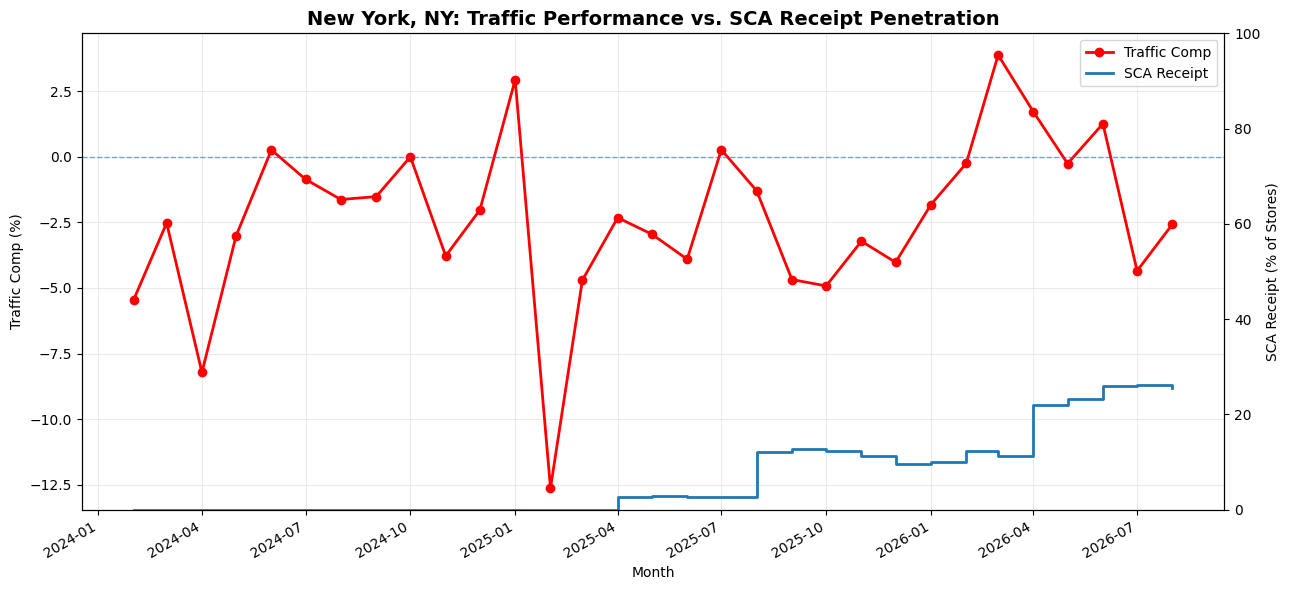

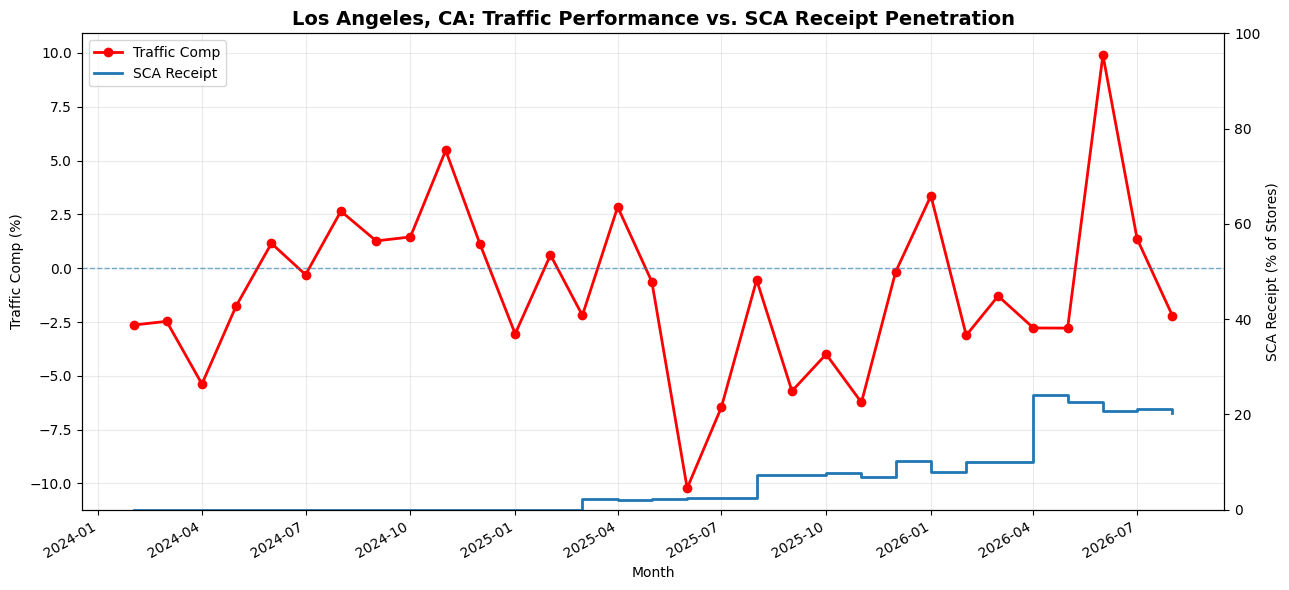

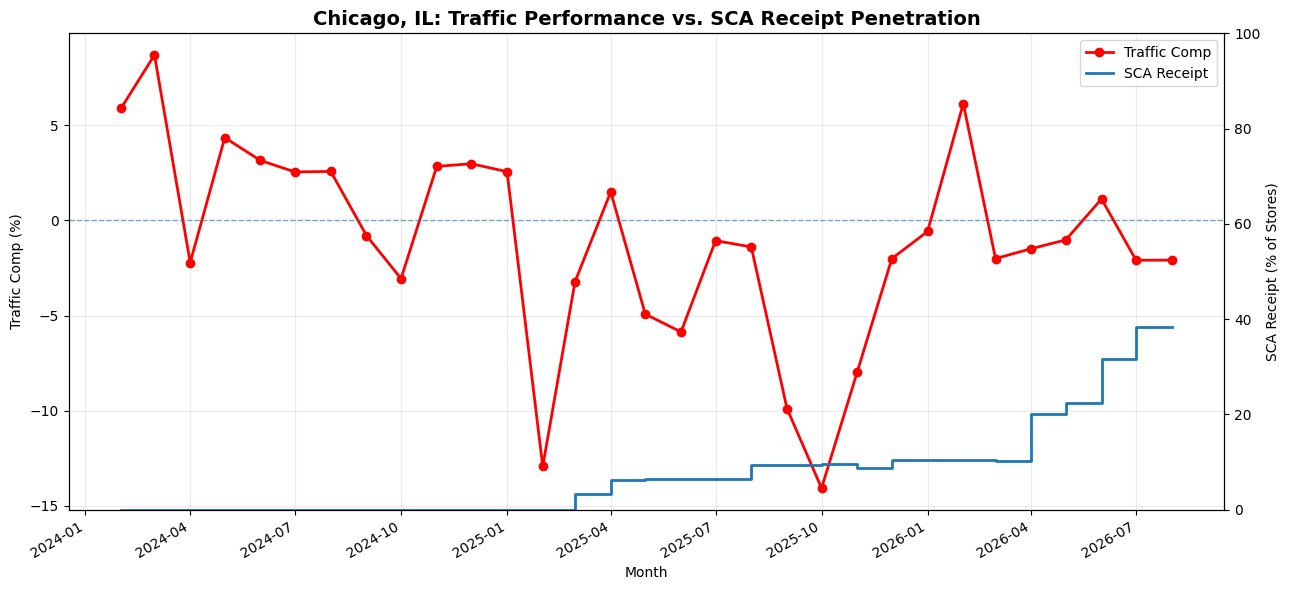

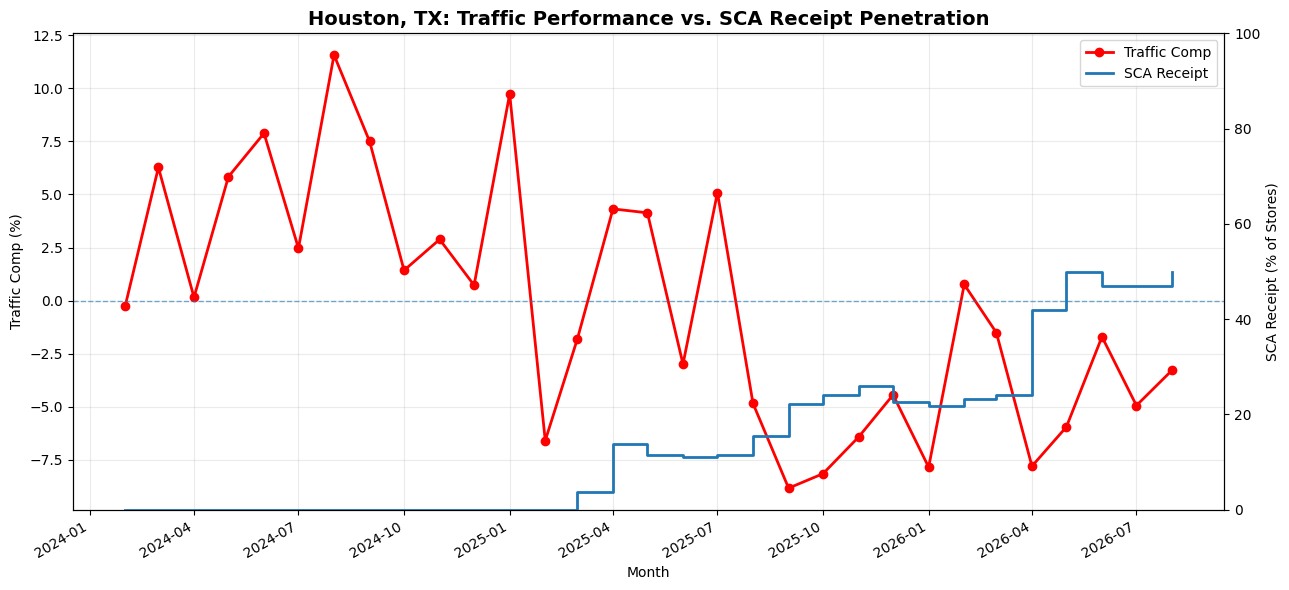

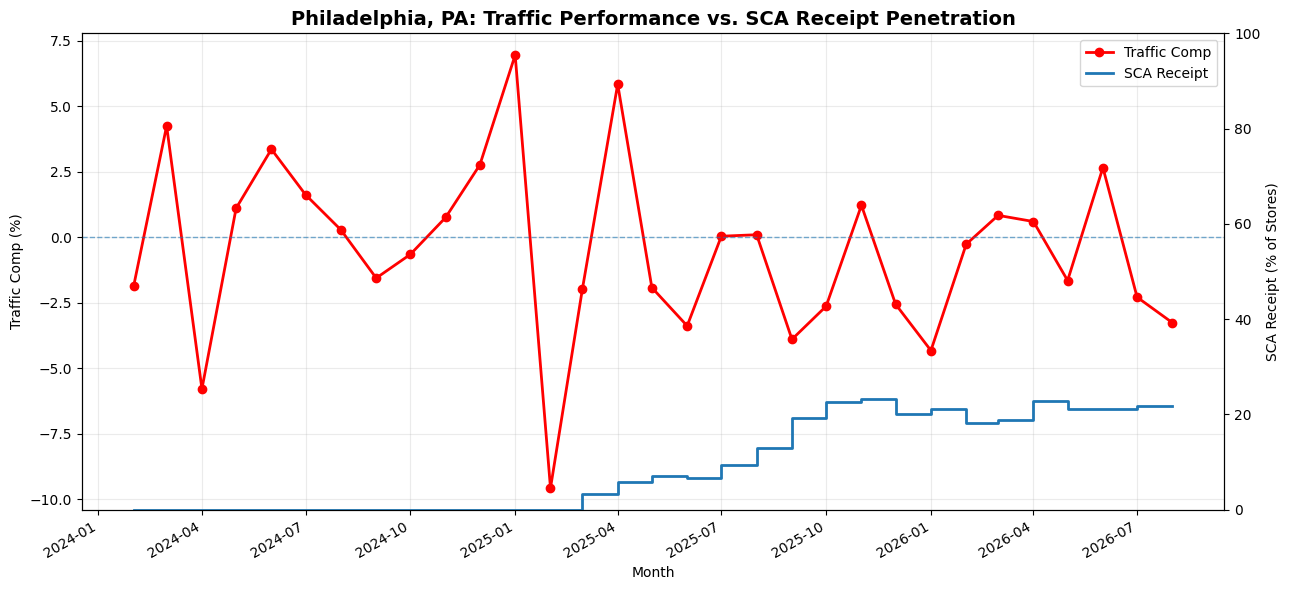

In [78]:
for dma in top_5_dmas:
    plot_dma_traffic_ap(
        dma_month_panel,
        dma,
        "SCA_Pct",
        "SCA Receipt"
    )

In [94]:
# ============================================================
# SCA EVENT TIME
# ============================================================

EVENT_WINDOW = 6
MIN_EXITS_LY = 500

sca_event = (
    store_month_panel
    .loc[
        store_month_panel["SCA_Rollout_Date"].notna()
        &
        store_month_panel["Exits_LY"].ge(MIN_EXITS_LY)
        &
        store_month_panel["Traffic_Comp"].notna()
    ]
    .copy()
)

# ------------------------------------------------------------
# Convert dates to monthly periods
# ------------------------------------------------------------

sca_event["SCA_Rollout_Month"] = (
    sca_event["SCA_Rollout_Date"]
    .dt.to_period("M")
)

sca_event["Traffic_Month"] = (
    sca_event["Date"]
    .dt.to_period("M")
)

# ------------------------------------------------------------
# Months relative to SCA implementation
# ------------------------------------------------------------

sca_event["Event_Month"] = (
    sca_event["Traffic_Month"]
    - sca_event["SCA_Rollout_Month"]
).apply(lambda x: x.n)

# ------------------------------------------------------------
# Restrict to event window
# ------------------------------------------------------------

sca_event = (
    sca_event.loc[
        sca_event["Event_Month"]
        .between(-EVENT_WINDOW, EVENT_WINDOW)
    ]
    .copy()
)

print("SCA Event-Month Coverage")
print("-" * 50)

print(
    sca_event["Event_Month"]
    .value_counts()
    .sort_index()
)

SCA Event-Month Coverage
--------------------------------------------------
Event_Month
-6    243
-5    244
-4    256
-3    261
-2    263
-1    262
 0    276
 1    273
 2    274
 3    267
 4    261
 5    129
 6    132
Name: count, dtype: int64


In [95]:
# ============================================================
# AVERAGE SCA EVENT TRAJECTORY
# ============================================================

sca_event_summary = (
    sca_event
    .groupby("Event_Month")
    .agg(
        Mean_Traffic_Comp=("Traffic_Comp", "mean"),
        Median_Traffic_Comp=("Traffic_Comp", "median"),
        Std_Traffic_Comp=("Traffic_Comp", "std"),
        Q25_Traffic_Comp=(
            "Traffic_Comp",
            lambda x: x.quantile(0.25)
        ),
        Q75_Traffic_Comp=(
            "Traffic_Comp",
            lambda x: x.quantile(0.75)
        ),
        N=("Store", "nunique"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Standard error
# ------------------------------------------------------------

sca_event_summary["SE"] = (
    sca_event_summary["Std_Traffic_Comp"]
    / np.sqrt(sca_event_summary["N"])
)

# ------------------------------------------------------------
# 95% confidence interval
# ------------------------------------------------------------

sca_event_summary["CI_Lower"] = (
    sca_event_summary["Mean_Traffic_Comp"]
    - 1.96 * sca_event_summary["SE"]
)

sca_event_summary["CI_Upper"] = (
    sca_event_summary["Mean_Traffic_Comp"]
    + 1.96 * sca_event_summary["SE"]
)

display(
    sca_event_summary.style.format({
        "Mean_Traffic_Comp": "{:.2%}",
        "Median_Traffic_Comp": "{:.2%}",
        "Std_Traffic_Comp": "{:.2%}",
        "Q25_Traffic_Comp": "{:.2%}",
        "Q75_Traffic_Comp": "{:.2%}",
        "SE": "{:.2%}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
    })
)

,Event_Month,Mean_Traffic_Comp,Median_Traffic_Comp,Std_Traffic_Comp,Q25_Traffic_Comp,Q75_Traffic_Comp,N,SE,CI_Lower,CI_Upper
0,-6,-2.35%,-2.49%,7.86%,-6.56%,2.07%,243,0.50%,-3.34%,-1.36%
1,-5,-0.08%,-0.04%,9.90%,-4.75%,4.04%,244,0.63%,-1.33%,1.16%
2,-4,-0.86%,0.20%,22.72%,-4.86%,5.42%,256,1.42%,-3.64%,1.92%
3,-3,-0.07%,-0.28%,8.10%,-4.73%,4.61%,261,0.50%,-1.05%,0.91%
4,-2,2.87%,2.64%,9.66%,-2.42%,7.20%,263,0.60%,1.71%,4.04%
5,-1,0.83%,0.69%,7.16%,-3.06%,4.96%,262,0.44%,-0.04%,1.70%
6,0,-1.92%,-0.19%,20.70%,-5.05%,4.70%,276,1.25%,-4.36%,0.52%
7,1,-0.76%,-0.86%,6.97%,-4.83%,3.68%,273,0.42%,-1.58%,0.07%
8,2,0.54%,0.66%,8.43%,-4.54%,4.98%,274,0.51%,-0.45%,1.54%
9,3,-1.56%,-1.68%,7.32%,-5.95%,2.01%,267,0.45%,-2.44%,-0.68%


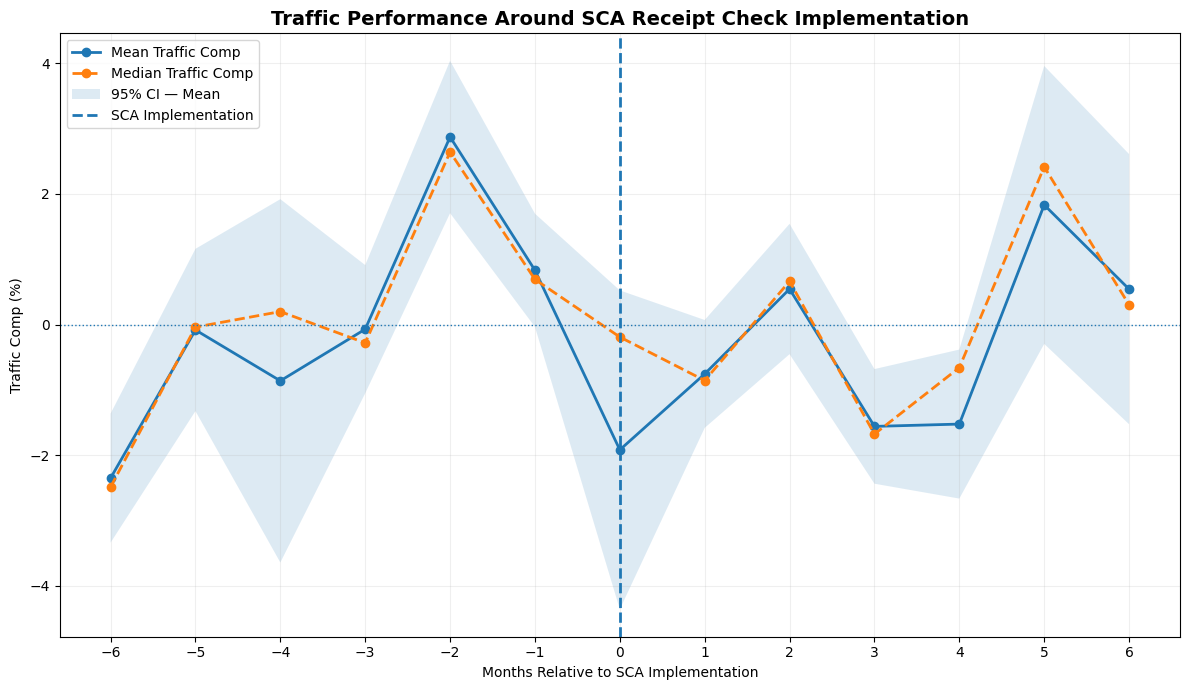

In [96]:
# ============================================================
# CLEANED SCA EVENT TRAJECTORY
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    sca_event_summary["Event_Month"],
    sca_event_summary["Mean_Traffic_Comp"] * 100,
    marker="o",
    linewidth=2,
    label="Mean Traffic Comp"
)

ax.plot(
    sca_event_summary["Event_Month"],
    sca_event_summary["Median_Traffic_Comp"] * 100,
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Median Traffic Comp"
)

ax.fill_between(
    sca_event_summary["Event_Month"],
    sca_event_summary["CI_Lower"] * 100,
    sca_event_summary["CI_Upper"] * 100,
    alpha=0.15,
    label="95% CI — Mean"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="SCA Implementation"
)

ax.axhline(
    0,
    linestyle=":",
    linewidth=1
)

ax.set_xticks(
    range(-EVENT_WINDOW, EVENT_WINDOW + 1)
)

ax.set_xlabel(
    "Months Relative to SCA Implementation"
)

ax.set_ylabel(
    "Traffic Comp (%)"
)

ax.set_title(
    "Traffic Performance Around SCA Receipt Check Implementation",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [104]:
# ============================================================
# PRIMARY SCA EVENT TRAJECTORY
# No additional baseline normalization
# ============================================================

sca_event_summary = (
    sca_event
    .groupby("Event_Month")
    .agg(
        Mean_Traffic_Comp=("Traffic_Comp", "mean"),
        Median_Traffic_Comp=("Traffic_Comp", "median"),
        Std_Traffic_Comp=("Traffic_Comp", "std"),
        Q25=("Traffic_Comp", lambda x: x.quantile(.25)),
        Q75=("Traffic_Comp", lambda x: x.quantile(.75)),
        N=("Store", "nunique"),
    )
    .reset_index()
)

sca_event_summary["SE"] = (
    sca_event_summary["Std_Traffic_Comp"]
    / np.sqrt(sca_event_summary["N"])
)

sca_event_summary["CI_Lower"] = (
    sca_event_summary["Mean_Traffic_Comp"]
    - 1.96 * sca_event_summary["SE"]
)

sca_event_summary["CI_Upper"] = (
    sca_event_summary["Mean_Traffic_Comp"]
    + 1.96 * sca_event_summary["SE"]
)

In [105]:
# ============================================================
# DEFINE PRE / POST WINDOWS
# ============================================================

PRE_START = -4
PRE_END = -2

POST_START = 1
POST_END = 4

MIN_PRE_MONTHS = 2
MIN_POST_MONTHS = 3


# ============================================================
# STORE-LEVEL PRE PERIOD
# ============================================================

sca_pre = (
    sca_event.loc[
        sca_event["Event_Month"]
        .between(PRE_START, PRE_END)
    ]
    .groupby("Store")
    .agg(
        Pre_Traffic_Comp=("Traffic_Comp", "mean"),
        Pre_Median_Traffic_Comp=("Traffic_Comp", "median"),
        Pre_Months=("Event_Month", "nunique"),
    )
    .reset_index()
)

sca_pre = (
    sca_pre.loc[
        sca_pre["Pre_Months"] >= MIN_PRE_MONTHS
    ]
    .copy()
)

# ============================================================
# STORE-LEVEL POST PERIOD
# ============================================================

sca_post = (
    sca_event.loc[
        sca_event["Event_Month"]
        .between(POST_START, POST_END)
    ]
    .groupby("Store")
    .agg(
        Post_Traffic_Comp=("Traffic_Comp", "mean"),
        Post_Median_Traffic_Comp=("Traffic_Comp", "median"),
        Post_Months=("Event_Month", "nunique"),
    )
    .reset_index()
)

sca_post = (
    sca_post.loc[
        sca_post["Post_Months"] >= MIN_POST_MONTHS
    ]
    .copy()
)

# ============================================================
# MATCH PRE + POST STORES
# ============================================================

sca_pre_post = (
    sca_pre
    .merge(
        sca_post,
        on="Store",
        how="inner"
    )
)

sca_pre_post["Traffic_Comp_Change"] = (
    sca_pre_post["Post_Traffic_Comp"]
    - sca_pre_post["Pre_Traffic_Comp"]
)

print(f"Stores analyzed: {len(sca_pre_post):,}")

print(
    f"Average Pre Traffic Comp: "
    f"{sca_pre_post['Pre_Traffic_Comp'].mean():.2%}"
)

print(
    f"Average Post Traffic Comp: "
    f"{sca_pre_post['Post_Traffic_Comp'].mean():.2%}"
)

print(
    f"Average Change: "
    f"{sca_pre_post['Traffic_Comp_Change'].mean():.2%}"
)

print(
    f"Median Change: "
    f"{sca_pre_post['Traffic_Comp_Change'].median():.2%}"
)


Stores analyzed: 241
Average Pre Traffic Comp: 1.25%
Average Post Traffic Comp: -1.01%
Average Change: -2.27%
Median Change: -1.80%


In [106]:
# ============================================================
# PAIRED PRE / POST TESTS
# ============================================================

from scipy.stats import ttest_rel, wilcoxon

# Paired t-test
t_stat, t_pvalue = ttest_rel(
    sca_pre_post["Post_Traffic_Comp"],
    sca_pre_post["Pre_Traffic_Comp"]
)

# Wilcoxon signed-rank
w_stat, w_pvalue = wilcoxon(
    sca_pre_post["Post_Traffic_Comp"],
    sca_pre_post["Pre_Traffic_Comp"]
)

print("Paired T-Test")
print("-" * 40)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {t_pvalue:.4f}")

print("\nWilcoxon Signed-Rank Test")
print("-" * 40)
print(f"Statistic: {w_stat:.3f}")
print(f"P-value:   {w_pvalue:.4f}")

Paired T-Test
----------------------------------------
T-statistic: -4.419
P-value:     0.0000

Wilcoxon Signed-Rank Test
----------------------------------------
Statistic: 9422.000
P-value:   0.0000


In [107]:
# ============================================================
# PRE / POST EFFECT ESTIMATE
# ============================================================

from scipy.stats import t

changes = (
    sca_pre_post["Traffic_Comp_Change"]
    .dropna()
)

mean_change = changes.mean()
median_change = changes.median()

se_change = (
    changes.std(ddof=1)
    / np.sqrt(len(changes))
)

critical_value = t.ppf(
    0.975,
    df=len(changes) - 1
)

ci_lower = (
    mean_change
    - critical_value * se_change
)

ci_upper = (
    mean_change
    + critical_value * se_change
)

print("SCA Pre/Post Traffic Analysis")
print("-" * 45)

print(f"Stores:             {len(changes):,}")
print(f"Mean Change:        {mean_change:.2%}")
print(f"Median Change:      {median_change:.2%}")
print(
    f"95% CI:             "
    f"[{ci_lower:.2%}, {ci_upper:.2%}]"
)

SCA Pre/Post Traffic Analysis
---------------------------------------------
Stores:             241
Mean Change:        -2.27%
Median Change:      -1.80%
95% CI:             [-3.28%, -1.26%]


### Metering Analysis


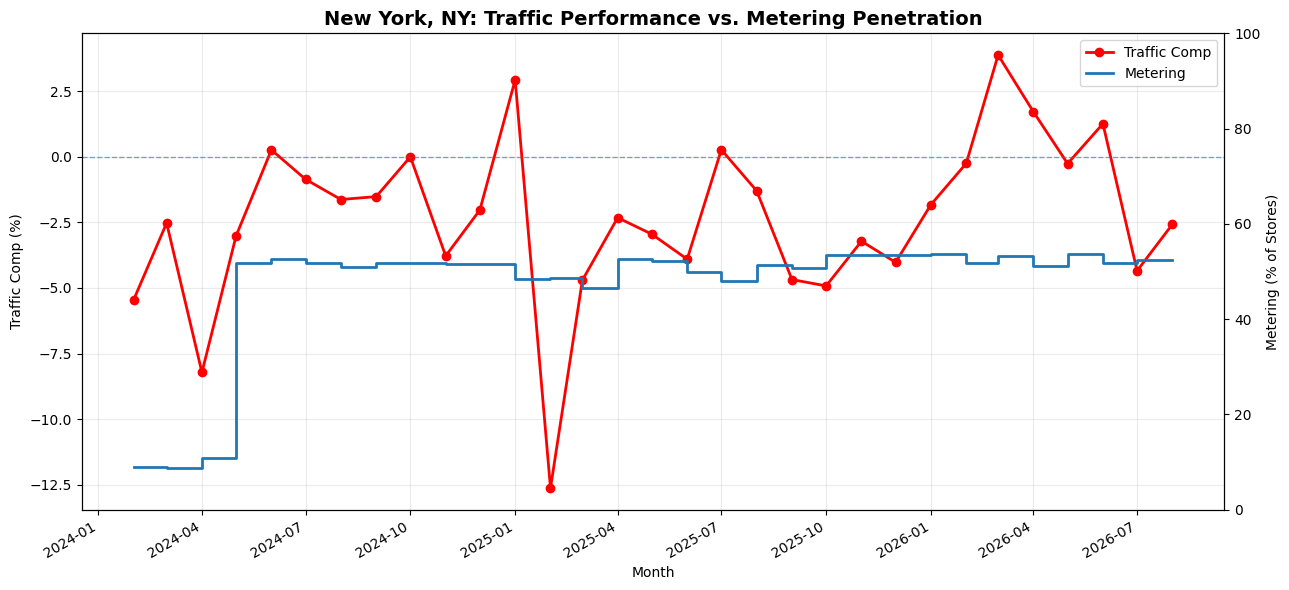

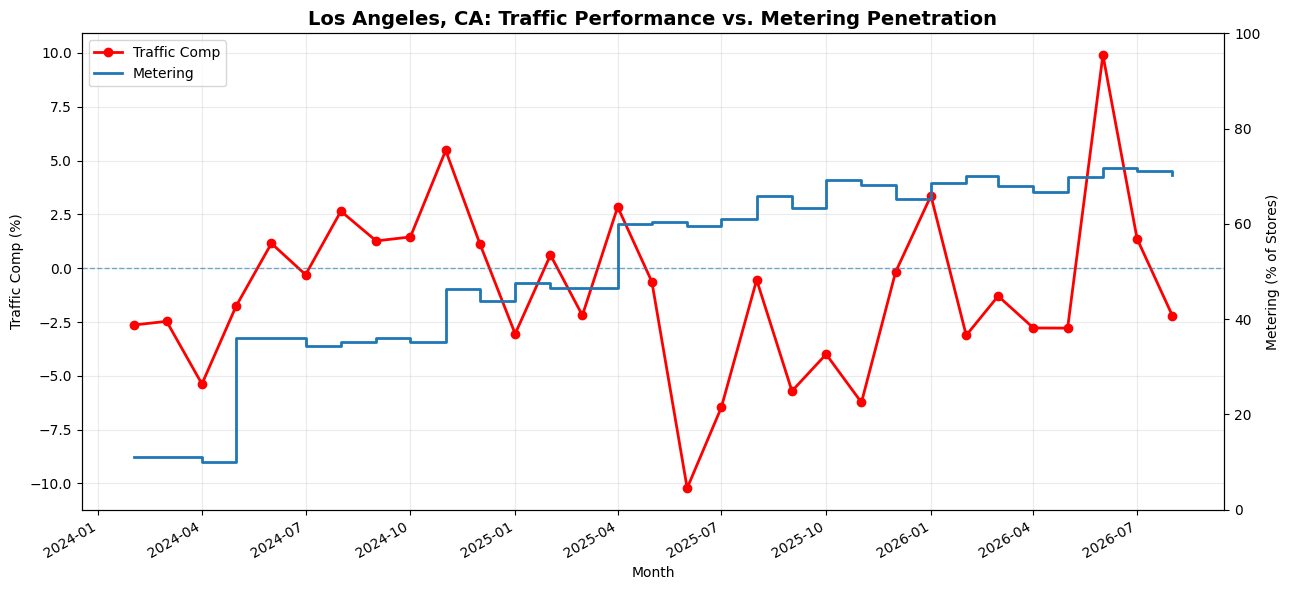

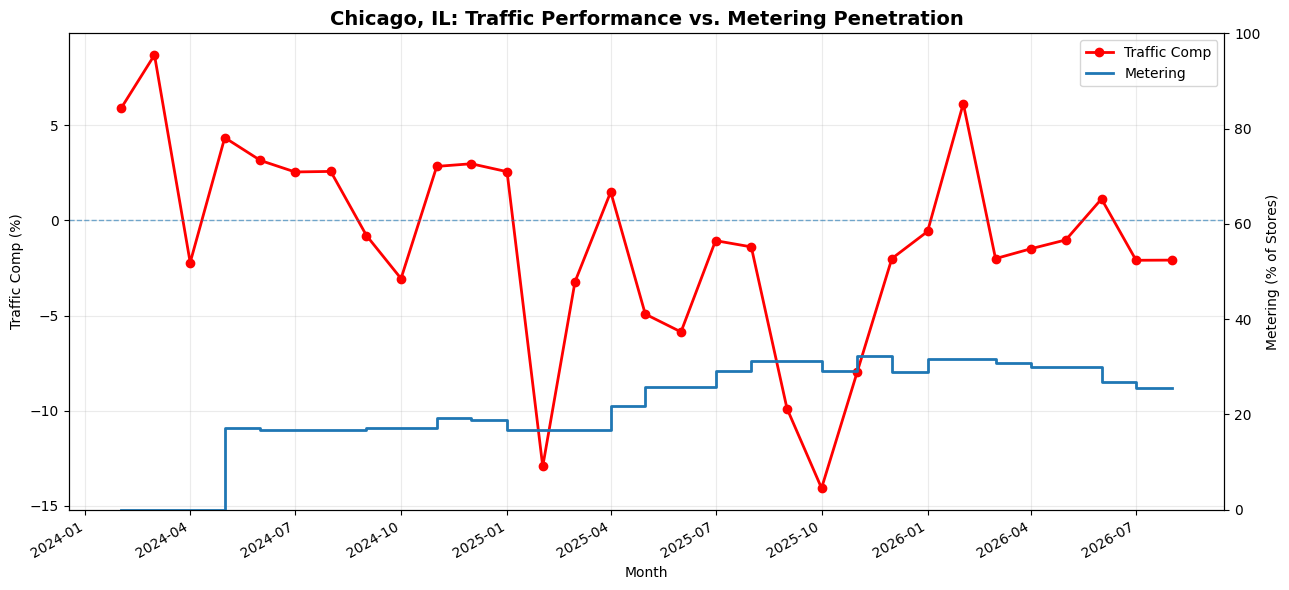

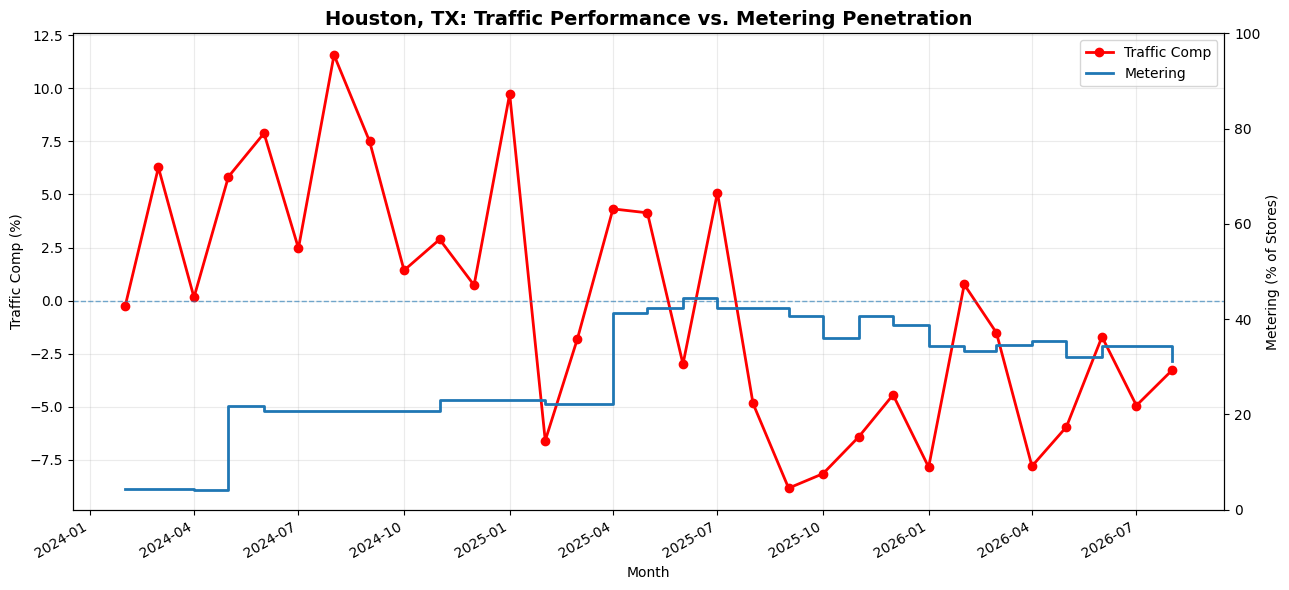

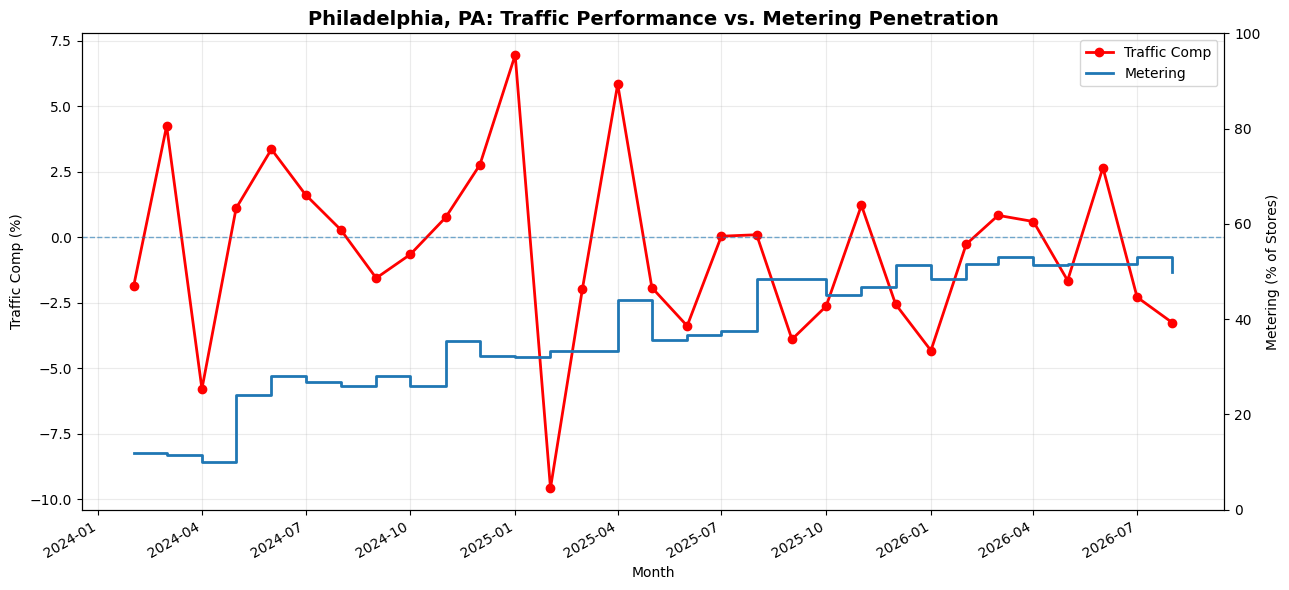

In [79]:
for dma in top_5_dmas:
    plot_dma_traffic_ap(
        dma_month_panel,
        dma,
        "Metering_Pct",
        "Metering"
    )

In [111]:
# ============================================================
# metering EVENT TIME
# ============================================================

EVENT_WINDOW = 6
MIN_EXITS_LY = 500

metering_event = (
    store_month_panel
    .loc[
        store_month_panel["Metering_Rollout_Date"].notna()
        &
        store_month_panel["Exits_LY"].ge(MIN_EXITS_LY)
        &
        store_month_panel["Traffic_Comp"].notna()
    ]
    .copy()
)

# ------------------------------------------------------------
# Convert dates to monthly periods
# ------------------------------------------------------------

metering_event["Metering_Rollout_Month"] = (
    metering_event["Metering_Rollout_Date"]
    .dt.to_period("M")
)

metering_event["Traffic_Month"] = (
    metering_event["Date"]
    .dt.to_period("M")
)

# ------------------------------------------------------------
# Months relative to metering implementation
# ------------------------------------------------------------

metering_event["Event_Month"] = (
    metering_event["Traffic_Month"]
    - metering_event["Metering_Rollout_Month"]
).apply(lambda x: x.n)

# ------------------------------------------------------------
# Restrict to event window
# ------------------------------------------------------------

metering_event = (
    metering_event.loc[
        metering_event["Event_Month"]
        .between(-EVENT_WINDOW, EVENT_WINDOW)
    ]
    .copy()
)

print("metering Event-Month Coverage")
print("-" * 50)

print(
    metering_event["Event_Month"]
    .value_counts()
    .sort_index()
)

metering Event-Month Coverage
--------------------------------------------------
Event_Month
-6    141
-5    141
-4    141
-3    224
-2    225
-1    230
 0    225
 1    229
 2    229
 3    228
 4    229
 5    230
 6    263
Name: count, dtype: int64


In [112]:
# ============================================================
# AVERAGE metering EVENT TRAJECTORY
# ============================================================

metering_event_summary = (
    metering_event
    .groupby("Event_Month")
    .agg(
        Mean_Traffic_Comp=("Traffic_Comp", "mean"),
        Median_Traffic_Comp=("Traffic_Comp", "median"),
        Std_Traffic_Comp=("Traffic_Comp", "std"),
        Q25_Traffic_Comp=(
            "Traffic_Comp",
            lambda x: x.quantile(0.25)
        ),
        Q75_Traffic_Comp=(
            "Traffic_Comp",
            lambda x: x.quantile(0.75)
        ),
        N=("Store", "nunique"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Standard error
# ------------------------------------------------------------

metering_event_summary["SE"] = (
    metering_event_summary["Std_Traffic_Comp"]
    / np.sqrt(metering_event_summary["N"])
)

# ------------------------------------------------------------
# 95% confidence interval
# ------------------------------------------------------------

metering_event_summary["CI_Lower"] = (
    metering_event_summary["Mean_Traffic_Comp"]
    - 1.96 * metering_event_summary["SE"]
)

metering_event_summary["CI_Upper"] = (
    metering_event_summary["Mean_Traffic_Comp"]
    + 1.96 * metering_event_summary["SE"]
)

display(
    metering_event_summary.style.format({
        "Mean_Traffic_Comp": "{:.2%}",
        "Median_Traffic_Comp": "{:.2%}",
        "Std_Traffic_Comp": "{:.2%}",
        "Q25_Traffic_Comp": "{:.2%}",
        "Q75_Traffic_Comp": "{:.2%}",
        "SE": "{:.2%}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
    })
)

,Event_Month,Mean_Traffic_Comp,Median_Traffic_Comp,Std_Traffic_Comp,Q25_Traffic_Comp,Q75_Traffic_Comp,N,SE,CI_Lower,CI_Upper
0,-6,-0.59%,-0.74%,8.54%,-6.02%,4.46%,141,0.72%,-2.00%,0.82%
1,-5,2.27%,1.64%,8.57%,-2.77%,7.03%,141,0.72%,0.86%,3.69%
2,-4,2.13%,3.22%,12.14%,-1.80%,6.87%,141,1.02%,0.13%,4.14%
3,-3,1.00%,1.25%,8.94%,-4.82%,6.84%,224,0.60%,-0.17%,2.17%
4,-2,-2.24%,-1.67%,8.73%,-7.98%,3.12%,225,0.58%,-3.38%,-1.10%
5,-1,-4.31%,-2.47%,13.49%,-8.41%,1.15%,230,0.89%,-6.05%,-2.57%
6,0,0.80%,0.94%,12.66%,-4.39%,5.49%,225,0.84%,-0.85%,2.46%
7,1,-1.71%,-1.30%,11.07%,-5.91%,3.80%,229,0.73%,-3.15%,-0.28%
8,2,-1.88%,-1.76%,9.80%,-8.15%,3.31%,229,0.65%,-3.15%,-0.61%
9,3,-1.76%,-1.76%,9.20%,-7.36%,3.74%,228,0.61%,-2.96%,-0.57%


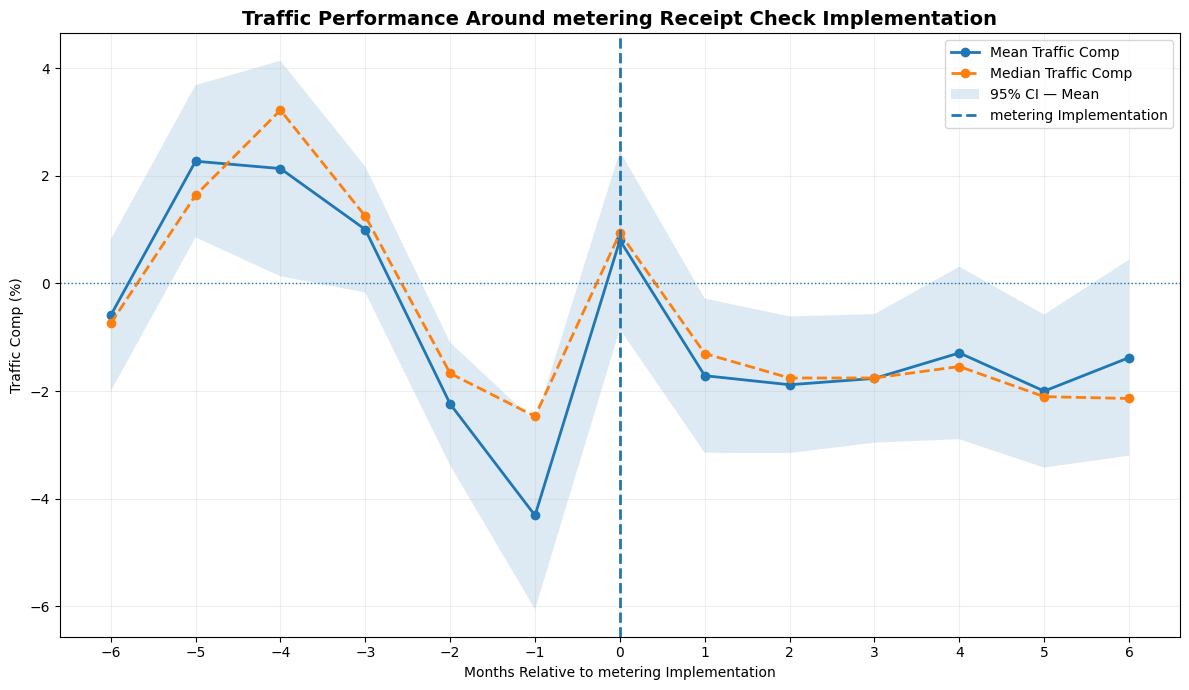

In [113]:
# ============================================================
# CLEANED metering EVENT TRAJECTORY
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    metering_event_summary["Event_Month"],
    metering_event_summary["Mean_Traffic_Comp"] * 100,
    marker="o",
    linewidth=2,
    label="Mean Traffic Comp"
)

ax.plot(
    metering_event_summary["Event_Month"],
    metering_event_summary["Median_Traffic_Comp"] * 100,
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Median Traffic Comp"
)

ax.fill_between(
    metering_event_summary["Event_Month"],
    metering_event_summary["CI_Lower"] * 100,
    metering_event_summary["CI_Upper"] * 100,
    alpha=0.15,
    label="95% CI — Mean"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="metering Implementation"
)

ax.axhline(
    0,
    linestyle=":",
    linewidth=1
)

ax.set_xticks(
    range(-EVENT_WINDOW, EVENT_WINDOW + 1)
)

ax.set_xlabel(
    "Months Relative to metering Implementation"
)

ax.set_ylabel(
    "Traffic Comp (%)"
)

ax.set_title(
    "Traffic Performance Around metering Receipt Check Implementation",
    fontsize=14,
    fontweight="bold"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [114]:
# ============================================================
# PRIMARY metering EVENT TRAJECTORY
# No additional baseline normalization
# ============================================================

metering_event_summary = (
    metering_event
    .groupby("Event_Month")
    .agg(
        Mean_Traffic_Comp=("Traffic_Comp", "mean"),
        Median_Traffic_Comp=("Traffic_Comp", "median"),
        Std_Traffic_Comp=("Traffic_Comp", "std"),
        Q25=("Traffic_Comp", lambda x: x.quantile(.25)),
        Q75=("Traffic_Comp", lambda x: x.quantile(.75)),
        N=("Store", "nunique"),
    )
    .reset_index()
)

metering_event_summary["SE"] = (
    metering_event_summary["Std_Traffic_Comp"]
    / np.sqrt(metering_event_summary["N"])
)

metering_event_summary["CI_Lower"] = (
    metering_event_summary["Mean_Traffic_Comp"]
    - 1.96 * metering_event_summary["SE"]
)

metering_event_summary["CI_Upper"] = (
    metering_event_summary["Mean_Traffic_Comp"]
    + 1.96 * metering_event_summary["SE"]
)

In [115]:
# ============================================================
# DEFINE PRE / POST WINDOWS
# ============================================================

PRE_START = -4
PRE_END = -2

POST_START = 1
POST_END = 4

MIN_PRE_MONTHS = 2
MIN_POST_MONTHS = 3


# ============================================================
# STORE-LEVEL PRE PERIOD
# ============================================================

metering_pre = (
    metering_event.loc[
        metering_event["Event_Month"]
        .between(PRE_START, PRE_END)
    ]
    .groupby("Store")
    .agg(
        Pre_Traffic_Comp=("Traffic_Comp", "mean"),
        Pre_Median_Traffic_Comp=("Traffic_Comp", "median"),
        Pre_Months=("Event_Month", "nunique"),
    )
    .reset_index()
)

metering_pre = (
    metering_pre.loc[
        metering_pre["Pre_Months"] >= MIN_PRE_MONTHS
    ]
    .copy()
)

# ============================================================
# STORE-LEVEL POST PERIOD
# ============================================================

metering_post = (
    metering_event.loc[
        metering_event["Event_Month"]
        .between(POST_START, POST_END)
    ]
    .groupby("Store")
    .agg(
        Post_Traffic_Comp=("Traffic_Comp", "mean"),
        Post_Median_Traffic_Comp=("Traffic_Comp", "median"),
        Post_Months=("Event_Month", "nunique"),
    )
    .reset_index()
)

metering_post = (
    metering_post.loc[
        metering_post["Post_Months"] >= MIN_POST_MONTHS
    ]
    .copy()
)

# ============================================================
# MATCH PRE + POST STORES
# ============================================================

metering_pre_post = (
    metering_pre
    .merge(
        metering_post,
        on="Store",
        how="inner"
    )
)

metering_pre_post["Traffic_Comp_Change"] = (
    metering_pre_post["Post_Traffic_Comp"]
    - metering_pre_post["Pre_Traffic_Comp"]
)

print(f"Stores analyzed: {len(metering_pre_post):,}")

print(
    f"Average Pre Traffic Comp: "
    f"{metering_pre_post['Pre_Traffic_Comp'].mean():.2%}"
)

print(
    f"Average Post Traffic Comp: "
    f"{metering_pre_post['Post_Traffic_Comp'].mean():.2%}"
)

print(
    f"Average Change: "
    f"{metering_pre_post['Traffic_Comp_Change'].mean():.2%}"
)

print(
    f"Median Change: "
    f"{metering_pre_post['Traffic_Comp_Change'].median():.2%}"
)


Stores analyzed: 213
Average Pre Traffic Comp: 0.12%
Average Post Traffic Comp: -1.40%
Average Change: -1.53%
Median Change: -2.19%


In [116]:
# ============================================================
# PAIRED PRE / POST TESTS
# ============================================================

from scipy.stats import ttest_rel, wilcoxon

# Paired t-test
t_stat, t_pvalue = ttest_rel(
    metering_pre_post["Post_Traffic_Comp"],
    metering_pre_post["Pre_Traffic_Comp"]
)

# Wilcoxon signed-rank
w_stat, w_pvalue = wilcoxon(
    metering_pre_post["Post_Traffic_Comp"],
    metering_pre_post["Pre_Traffic_Comp"]
)

print("Paired T-Test")
print("-" * 40)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {t_pvalue:.4f}")

print("\nWilcoxon Signed-Rank Test")
print("-" * 40)
print(f"Statistic: {w_stat:.3f}")
print(f"P-value:   {w_pvalue:.4f}")

Paired T-Test
----------------------------------------
T-statistic: -2.532
P-value:     0.0121

Wilcoxon Signed-Rank Test
----------------------------------------
Statistic: 8097.000
P-value:   0.0002


In [117]:
# ============================================================
# PRE / POST EFFECT ESTIMATE
# ============================================================

from scipy.stats import t

changes = (
    metering_pre_post["Traffic_Comp_Change"]
    .dropna()
)

mean_change = changes.mean()
median_change = changes.median()

se_change = (
    changes.std(ddof=1)
    / np.sqrt(len(changes))
)

critical_value = t.ppf(
    0.975,
    df=len(changes) - 1
)

ci_lower = (
    mean_change
    - critical_value * se_change
)

ci_upper = (
    mean_change
    + critical_value * se_change
)

print("metering Pre/Post Traffic Analysis")
print("-" * 45)

print(f"Stores:             {len(changes):,}")
print(f"Mean Change:        {mean_change:.2%}")
print(f"Median Change:      {median_change:.2%}")
print(
    f"95% CI:             "
    f"[{ci_lower:.2%}, {ci_upper:.2%}]"
)

metering Pre/Post Traffic Analysis
---------------------------------------------
Stores:             213
Mean Change:        -1.53%
Median Change:      -2.19%
95% CI:             [-2.71%, -0.34%]


## Fixed Effects analysis

In [118]:
# ============================================================
# PREPARE FIXED-EFFECTS PANEL
# ============================================================

import numpy as np
import pandas as pd


def prepare_fe_panel(
    df,
    rollout_col,
    min_exits_ly=500,
    outcome_col="Traffic_Comp",
):
    """
    Prepare a store-month panel for AP fixed-effects analysis.

    Parameters
    ----------
    df : pd.DataFrame
        Store-month panel.

    rollout_col : str
        AP rollout-date column.

    min_exits_ly : int
        Minimum prior-year exits required for valid traffic comp.

    outcome_col : str
        Outcome variable used in the model.

    Returns
    -------
    pd.DataFrame
        Clean modeling panel.
    """

    panel = df.copy()

    # --------------------------------------------------------
    # Require valid store / date / outcome
    # --------------------------------------------------------

    panel = panel.loc[
        panel["Store"].notna()
        &
        panel["Date"].notna()
        &
        panel[outcome_col].notna()
        &
        panel["Exits_LY"].ge(min_exits_ly)
    ].copy()

    # --------------------------------------------------------
    # Ensure date formats
    # --------------------------------------------------------

    panel["Date"] = pd.to_datetime(
        panel["Date"],
        errors="coerce"
    )

    panel[rollout_col] = pd.to_datetime(
        panel[rollout_col],
        errors="coerce"
    )

    # Calendar month FE variable
    panel["Calendar_Month"] = (
        panel["Date"]
        .dt.to_period("M")
        .astype(str)
    )

    # --------------------------------------------------------
    # Treatment indicator
    # --------------------------------------------------------

    rollout_month = (
        panel[rollout_col]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    panel["Treatment_Active"] = (
        panel[rollout_col].notna()
        &
        (panel["Date"] >= rollout_month)
    ).astype(int)

    # --------------------------------------------------------
    # Event time
    # --------------------------------------------------------

    panel["Traffic_Period"] = (
        panel["Date"]
        .dt.to_period("M")
    )

    panel["Rollout_Period"] = (
        panel[rollout_col]
        .dt.to_period("M")
    )

    panel["Event_Month"] = pd.NA

    treated_mask = (
        panel["Rollout_Period"].notna()
    )

    panel.loc[
        treated_mask,
        "Event_Month"
    ] = (
        panel.loc[
            treated_mask,
            "Traffic_Period"
        ]
        -
        panel.loc[
            treated_mask,
            "Rollout_Period"
        ]
    ).apply(lambda x: x.n)

    panel["Event_Month"] = pd.to_numeric(
        panel["Event_Month"],
        errors="coerce"
    )

    return panel

In [119]:
sca_fe_panel = prepare_fe_panel(
    store_month_panel,
    rollout_col="SCA_Rollout_Date"
)

metering_fe_panel = prepare_fe_panel(
    store_month_panel,
    rollout_col="Metering_Rollout_Date"
)

In [120]:
# ============================================================
# FIXED-EFFECTS PANEL SUMMARY
# ============================================================

def summarize_fe_panel(
    panel,
    outcome_col="Traffic_Comp"
):
    """
    Summarize the modeling panel before fixed-effects analysis.
    """

    treated_stores = (
        panel.loc[
            panel["Rollout_Period"].notna(),
            "Store"
        ]
        .nunique()
    )

    never_treated_stores = (
        panel.loc[
            panel["Rollout_Period"].isna(),
            "Store"
        ]
        .nunique()
    )

    summary = pd.Series({
        "Observations": len(panel),

        "Stores":
            panel["Store"].nunique(),

        "Calendar Months":
            panel["Calendar_Month"].nunique(),

        "Treated Stores":
            treated_stores,

        "Never-Treated Stores":
            never_treated_stores,

        "Pre-Treatment Observations":
            (
                panel["Event_Month"] < 0
            ).sum(),

        "Post-Treatment Observations":
            (
                panel["Event_Month"] >= 0
            ).sum(),

        "Mean Traffic Comp":
            panel[outcome_col].mean(),

        "Median Traffic Comp":
            panel[outcome_col].median(),
    })

    return summary

In [121]:
display(
    summarize_fe_panel(
        sca_fe_panel
    ).to_frame("SCA")
)

display(
    summarize_fe_panel(
        metering_fe_panel
    ).to_frame("Metering")
)

,SCA
Observations,25333.000000
Stores,1081.000000
Calendar Months,31.000000
Treated Stores,329.000000
Never-Treated Stores,752.000000
Pre-Treatment Observations,5163.000000
Post-Treatment Observations,2672.000000
Mean Traffic Comp,-0.000636
Median Traffic Comp,0.000591


,Metering
Observations,25333.000000
Stores,1081.000000
Calendar Months,31.000000
Treated Stores,354.000000
Never-Treated Stores,727.000000
Pre-Treatment Observations,2148.000000
Post-Treatment Observations,6324.000000
Mean Traffic Comp,-0.000636
Median Traffic Comp,0.000591


In [122]:
# ============================================================
# TWO-WAY FIXED-EFFECTS MODEL
# ============================================================

import statsmodels.formula.api as smf


def fit_fe_treatment_model(
    panel,
    outcome_col="Traffic_Comp"
):
    """
    Estimate:

        Outcome ~ Treatment
                  + Store FE
                  + Calendar Month FE

    Standard errors are clustered by Store.
    """

    formula = (
        f"{outcome_col} ~ "
        "Treatment_Active "
        "+ C(Store) "
        "+ C(Calendar_Month)"
    )

    model = smf.ols(
        formula=formula,
        data=panel
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": panel["Store"]
        }
    )

    return model

In [123]:
sca_fe_model = fit_fe_treatment_model(
    sca_fe_panel
)

print(
    sca_fe_model.summary()
)

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1111, but rank is 31
  res = self.wald_test(


                            OLS Regression Results                            
Dep. Variable:           Traffic_Comp   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                 8.115e+12
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:50:39   Log-Likelihood:                 22680.
No. Observations:               25333   AIC:                        -4.314e+04
Df Residuals:                   24221   BIC:                        -3.408e+04
Df Model:                        1111                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [124]:
metering_fe_model = fit_fe_treatment_model(
    metering_fe_panel
)

print(
    metering_fe_model.summary()
)

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1111, but rank is 31
  res = self.wald_test(


                            OLS Regression Results                            
Dep. Variable:           Traffic_Comp   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                -2.833e+12
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               1.00
Time:                        12:53:55   Log-Likelihood:                 22687.
No. Observations:               25333   AIC:                        -4.315e+04
Df Residuals:                   24221   BIC:                        -3.410e+04
Df Model:                        1111                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [125]:
# ============================================================
# EXTRACT FE TREATMENT RESULT
# ============================================================

def extract_fe_result(
    model,
    term="Treatment_Active"
):
    """
    Extract the main treatment coefficient and inference.
    """

    result = pd.DataFrame({
        "Coefficient": [
            model.params[term]
        ],
        "Std_Error": [
            model.bse[term]
        ],
        "T_Statistic": [
            model.tvalues[term]
        ],
        "P_Value": [
            model.pvalues[term]
        ],
        "CI_Lower": [
            model.conf_int().loc[
                term, 0
            ]
        ],
        "CI_Upper": [
            model.conf_int().loc[
                term, 1
            ]
        ],
    })

    return result

In [127]:
sca_fe_result = extract_fe_result(
    sca_fe_model
)

metering_fe_result = extract_fe_result(
    metering_fe_model
)

display(
    sca_fe_result.style.format({
        "Coefficient": "{:.2%}",
        "Std_Error": "{:.2%}",
        "T_Statistic": "{:.3f}",
        "P_Value": "{:.4f}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
    })
)

display(
    metering_fe_result.style.format({
        "Coefficient": "{:.2%}",
        "Std_Error": "{:.2%}",
        "T_Statistic": "{:.3f}",
        "P_Value": "{:.4f}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
    })
)

,Coefficient,Std_Error,T_Statistic,P_Value,CI_Lower,CI_Upper
0,-0.64%,0.62%,-1.023,0.3065,-1.86%,0.58%


,Coefficient,Std_Error,T_Statistic,P_Value,CI_Lower,CI_Upper
0,-1.38%,0.75%,-1.834,0.0667,-2.85%,0.10%


### Event Modeling

In [128]:
# ============================================================
# CREATE EVENT-TIME BINS
# ============================================================

def create_event_time_bins(
    panel,
    pre_bin=-6,
    post_bin=6
):
    """
    Bin event time into a fixed window.

    Example:
        <= -6 becomes -6
        >= +6 becomes +6

    Never-treated stores retain NaN event time.
    """

    df = panel.copy()

    df["Event_Time_Binned"] = (
        df["Event_Month"]
        .clip(
            lower=pre_bin,
            upper=post_bin
        )
    )

    return df

In [129]:
sca_fe_panel = create_event_time_bins(
    sca_fe_panel
)

metering_fe_panel = create_event_time_bins(
    metering_fe_panel
)

In [130]:
# ============================================================
# CREATE EVENT-STUDY DUMMIES
# ============================================================

def create_event_dummies(
    panel,
    pre_bin=-6,
    post_bin=6,
    reference_period=-1
):
    """
    Create event-time dummy variables.

    Reference period is omitted from the model.
    """

    df = panel.copy()

    event_cols = {}

    for event_time in range(
        pre_bin,
        post_bin + 1
    ):

        if event_time == reference_period:
            continue

        if event_time < 0:
            col = f"event_m{abs(event_time)}"

        elif event_time == 0:
            col = "event_0"

        else:
            col = f"event_p{event_time}"

        df[col] = (
            df["Event_Time_Binned"]
            .eq(event_time)
            .astype(int)
        )

        event_cols[event_time] = col

    return df, event_cols

In [131]:
sca_event_panel, sca_event_cols = (
    create_event_dummies(
        sca_fe_panel
    )
)

metering_event_panel, metering_event_cols =(
    create_event_dummies(
        metering_fe_panel

    )
)

In [132]:
# ============================================================
# FIT FIXED-EFFECTS EVENT STUDY
# ============================================================

def fit_fe_event_study(
    panel,
    event_cols,
    outcome_col="Traffic_Comp"
):
    """
    Estimate event-time coefficients with:

        Store fixed effects
        Calendar-month fixed effects
        Store-clustered standard errors
    """

    event_terms = " + ".join(
        event_cols.values()
    )

    formula = (
        f"{outcome_col} ~ "
        f"{event_terms} "
        "+ C(Store) "
        "+ C(Calendar_Month)"
    )

    model = smf.ols(
        formula=formula,
        data=panel
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": panel["Store"]
        }
    )

    return model


In [133]:
sca_event_model = (
    fit_fe_event_study(
        sca_event_panel,
        sca_event_cols
    )
)

In [134]:
metering_event_model =(
    fit_fe_event_study(
        metering_event_panel,
        metering_event_cols
    )
)

In [135]:
# ============================================================
# EXTRACT EVENT-STUDY RESULTS
# ============================================================

def extract_event_study_results(
    model,
    event_cols,
    reference_period=-1
):
    """
    Extract event-study coefficients and add
    the reference period as zero.
    """

    rows = []

    conf_int = model.conf_int()

    for event_time, col in event_cols.items():

        rows.append({
            "Event_Month": event_time,

            "Coefficient":
                model.params[col],

            "Std_Error":
                model.bse[col],

            "T_Statistic":
                model.tvalues[col],

            "P_Value":
                model.pvalues[col],

            "CI_Lower":
                conf_int.loc[col, 0],

            "CI_Upper":
                conf_int.loc[col, 1],
        })

    # Add omitted reference period
    rows.append({
        "Event_Month":
            reference_period,

        "Coefficient":
            0.0,

        "Std_Error":
            np.nan,

        "T_Statistic":
            np.nan,

        "P_Value":
            np.nan,

        "CI_Lower":
            0.0,

        "CI_Upper":
            0.0,
    })

    results = (
        pd.DataFrame(rows)
        .sort_values("Event_Month")
        .reset_index(drop=True)
    )

    return results

In [136]:
sca_event_results = (
    extract_event_study_results(
        sca_event_model,
        sca_event_cols
    )
)

metering_event_results =(
    extract_event_study_results(
        metering_event_model,
        metering_event_cols
    )
)

display(
    sca_event_results.style.format({
        "Coefficient": "{:.2%}",
        "Std_Error": "{:.2%}",
        "T_Statistic": "{:.3f}",
        "P_Value": "{:.4f}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
    })
)

display(
    metering_event_results.style.format({
        "Coefficient": "{:.2%}",
        "Std_Error": "{:.2%}",
        "T_Statistic": "{:.3f}",
        "P_Value": "{:.4f}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
    })
)

,Event_Month,Coefficient,Std_Error,T_Statistic,P_Value,CI_Lower,CI_Upper
0,-6,0.06%,0.63%,0.097,0.9229,-1.18%,1.30%
1,-5,0.29%,0.62%,0.474,0.6353,-0.91%,1.50%
2,-4,-0.68%,1.36%,-0.497,0.6190,-3.34%,1.99%
3,-3,0.40%,0.53%,0.763,0.4452,-0.63%,1.43%
4,-2,0.98%,0.52%,1.891,0.0586,-0.04%,2.00%
5,-1,0.00%,nan%,nan,nan,0.00%,0.00%
6,0,-1.56%,1.13%,-1.383,0.1666,-3.77%,0.65%
7,1,-0.07%,0.43%,-0.163,0.8708,-0.92%,0.78%
8,2,-0.17%,0.53%,-0.314,0.7535,-1.20%,0.87%
9,3,-0.08%,0.52%,-0.159,0.8737,-1.11%,0.94%


,Event_Month,Coefficient,Std_Error,T_Statistic,P_Value,CI_Lower,CI_Upper
0,-6,2.68%,1.07%,2.499,0.0125,0.58%,4.78%
1,-5,2.54%,1.00%,2.548,0.0108,0.59%,4.49%
2,-4,2.01%,1.24%,1.620,0.1053,-0.42%,4.44%
3,-3,0.60%,0.86%,0.697,0.4859,-1.09%,2.28%
4,-2,0.80%,0.80%,0.997,0.3186,-0.77%,2.37%
5,-1,0.00%,nan%,nan,nan,0.00%,0.00%
6,0,0.59%,0.98%,0.594,0.5522,-1.34%,2.51%
7,1,-0.10%,1.01%,-0.103,0.9176,-2.07%,1.87%
8,2,0.19%,0.95%,0.195,0.8456,-1.68%,2.05%
9,3,0.18%,0.87%,0.201,0.8405,-1.54%,1.89%


Overall, the results indicate no statistically significant findings regarding SCA measures and observable variations in store traffic.  Conversely, Metering shows a highly suggestive modest impact on traffic decline, but also not statistically significant.  Additionally, the data shows traffic was already declining prior to metering and/or SCA implementation.

### Joint Testing


In [137]:
# ============================================================
# JOINT PRE-TREND TEST
# ============================================================

def test_pre_trends(
    model,
    event_cols,
    pre_periods=(-6, -5, -4, -3, -2)
):
    """
    Jointly test whether all pre-treatment event coefficients
    are equal to zero.
    """

    terms = [
        event_cols[event_time]
        for event_time in pre_periods
        if event_time in event_cols
    ]

    hypothesis = " = 0, ".join(terms) + " = 0"

    test = model.f_test(hypothesis)

    return {
        "F_Statistic": float(test.fvalue),
        "P_Value": float(test.pvalue),
        "DF_Num": int(test.df_num),
        "DF_Denom": float(test.df_denom),
    }

In [138]:
sca_pretrend_test = test_pre_trends(
    sca_event_model,
    sca_event_cols
)

metering_pretrend_test = test_pre_trends(
    metering_event_model,
    metering_event_cols
)

print("SCA Pre-Trend Test")
print(sca_pretrend_test)

print("\nMetering Pre-Trend Test")
print(metering_pretrend_test)

SCA Pre-Trend Test
{'F_Statistic': 0.8775751433047269, 'P_Value': 0.49540731197161303, 'DF_Num': 5, 'DF_Denom': 1080.0}

Metering Pre-Trend Test
{'F_Statistic': 2.0145632793715005, 'P_Value': 0.07410863748064278, 'DF_Num': 5, 'DF_Denom': 1080.0}


After controlling for persistent differences between stores and common monthly traffic conditions, the analysis finds **no statistically significant evidence that either SCA Receipt Checks or Metering negatively impacts store traffic**.

The initial pre/post analysis showed lower traffic performance following implementation; however, these differences became substantially smaller and statistically insignificant after introducing store and calendar-month fixed effects. The estimated traffic effect was **-0.64 percentage points for SCA** and **-1.38 percentage points for Metering**, with neither estimate statistically significant at the 5% level.

The event-study analysis provides additional context. Neither SCA nor Metering showed statistically significant negative traffic effects in the months following implementation. For Metering, traffic performance appears to have been weakening prior to implementation, although the overall pre-treatment trend was not statistically significant at the 5% level.

This pattern is consistent with AP measures being implemented in stores that may already face conditions associated with weaker traffic performance, rather than the AP measures themselves causing the decline. Store-level characteristics not captured in the available data—such as shrink exposure, theft activity, market conditions, store operating characteristics, or other local factors—may influence both the decision to deploy AP measures and traffic performance.

Overall, the analysis **does not provide evidence that SCA Receipt Checks or Metering cause a measurable negative drag on store traffic**. Instead, the results suggest that differences observed in the simpler pre/post analysis are more likely associated with underlying store and time-related factors that coincide with AP deployment.


## AP Impact Visualization

In [139]:
# ============================================================
# BUILD AP IMPACT PROGRESSION
# ============================================================

def build_ap_impact_progression(
    measure,
    prepost_df,
    fe_result,
    change_col="Traffic_Comp_Change"
):
    """
    Build a standardized table showing how the estimated
    AP traffic impact changes across model specifications.

    Stages
    ------
    1. Raw matched pre/post comparison
    2. Store + calendar-month fixed effects

    Parameters
    ----------
    measure : str
        Display name for the AP measure.

    prepost_df : pd.DataFrame
        Store-level matched pre/post results.

    fe_result : pd.DataFrame
        Output from extract_fe_result().

    change_col : str
        Store-level pre/post change variable.

    Returns
    -------
    pd.DataFrame
    """

    from scipy.stats import t

    # --------------------------------------------------------
    # 1. RAW PRE / POST
    # --------------------------------------------------------

    changes = (
        prepost_df[change_col]
        .dropna()
    )

    n = len(changes)

    estimate = changes.mean()

    se = (
        changes.std(ddof=1)
        / np.sqrt(n)
    )

    critical = t.ppf(
        0.975,
        df=n - 1
    )

    prepost_lower = (
        estimate - critical * se
    )

    prepost_upper = (
        estimate + critical * se
    )

    # --------------------------------------------------------
    # 2. TWO-WAY FIXED EFFECTS
    # --------------------------------------------------------

    fe_estimate = (
        fe_result["Coefficient"].iloc[0]
    )

    fe_lower = (
        fe_result["CI_Lower"].iloc[0]
    )

    fe_upper = (
        fe_result["CI_Upper"].iloc[0]
    )

    fe_p = (
        fe_result["P_Value"].iloc[0]
    )

    # --------------------------------------------------------
    # COMBINE
    # --------------------------------------------------------

    progression = pd.DataFrame({

        "Measure": [
            measure,
            measure
        ],

        "Model": [
            "Raw Pre/Post",
            "Store + Month FE"
        ],

        "Estimate": [
            estimate,
            fe_estimate
        ],

        "CI_Lower": [
            prepost_lower,
            fe_lower
        ],

        "CI_Upper": [
            prepost_upper,
            fe_upper
        ],

        "P_Value": [
            np.nan,
            fe_p
        ]
    })

    return progression

In [140]:
sca_progression = build_ap_impact_progression(
    measure="SCA Receipt Checks",
    prepost_df=sca_pre_post,
    fe_result=sca_fe_result
)


metering_progression = build_ap_impact_progression(
    measure="Metering",
    prepost_df=metering_pre_post,
    fe_result=metering_fe_result
)

In [141]:
ap_progression = pd.concat(
    [
        sca_progression,
        metering_progression
    ],
    ignore_index=True
)

display(
    ap_progression.style.format({
        "Estimate": "{:.2%}",
        "CI_Lower": "{:.2%}",
        "CI_Upper": "{:.2%}",
        "P_Value": "{:.4f}",
    })
)

,Measure,Model,Estimate,CI_Lower,CI_Upper,P_Value
0,SCA Receipt Checks,Raw Pre/Post,-2.27%,-3.28%,-1.26%,nan
1,SCA Receipt Checks,Store + Month FE,-0.64%,-1.86%,0.58%,0.3065
2,Metering,Raw Pre/Post,-1.53%,-2.71%,-0.34%,nan
3,Metering,Store + Month FE,-1.38%,-2.85%,0.10%,0.0667


In [142]:
# ============================================================
# AP IMPACT PROGRESSION PLOT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


def plot_ap_impact_progression(
    progression_df,
    measure
):
    """
    Plot raw pre/post and fixed-effects estimates
    with 95% confidence intervals.
    """

    temp = (
        progression_df.loc[
            progression_df["Measure"] == measure
        ]
        .copy()
    )

    model_order = [
        "Raw Pre/Post",
        "Store + Month FE"
    ]

    temp["Model"] = pd.Categorical(
        temp["Model"],
        categories=model_order,
        ordered=True
    )

    temp = (
        temp
        .sort_values("Model")
        .reset_index(drop=True)
    )

    # Convert to percentage points
    estimate = (
        temp["Estimate"].to_numpy()
        * 100
    )

    lower = (
        temp["CI_Lower"].to_numpy()
        * 100
    )

    upper = (
        temp["CI_Upper"].to_numpy()
        * 100
    )

    error_lower = (
        estimate - lower
    )

    error_upper = (
        upper - estimate
    )

    x = np.arange(len(temp))

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.errorbar(
        x,
        estimate,
        yerr=[
            error_lower,
            error_upper
        ],
        fmt="o",
        markersize=9,
        capsize=6,
        linewidth=2
    )

    # Connect estimates to emphasize progression
    ax.plot(
        x,
        estimate,
        linestyle="--",
        alpha=0.5
    )

    # Zero-effect line
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    # --------------------------------------------------------
    # LABEL ESTIMATES
    # --------------------------------------------------------

    for i, value in enumerate(estimate):

        ax.annotate(
            f"{value:.2f} pp",
            xy=(i, value),
            xytext=(0, -22),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xticks(x)

    ax.set_xticklabels([
        "Raw\nPre/Post",
        "Store + Month\nFixed Effects"
    ])

    ax.set_ylabel(
        "Estimated Change in Traffic Comp\n(Percentage Points)"
    )

    ax.set_title(
        f"{measure}: Estimated Traffic Impact",
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

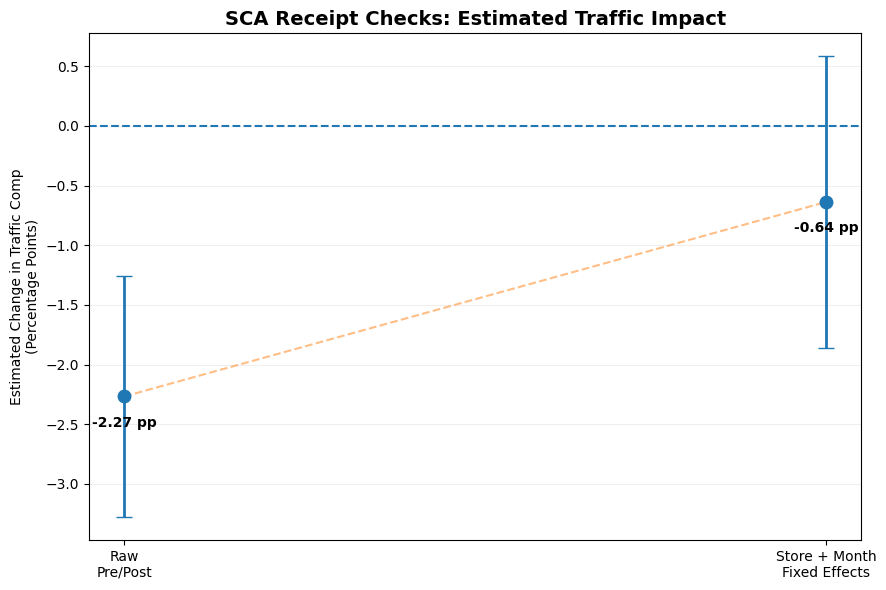

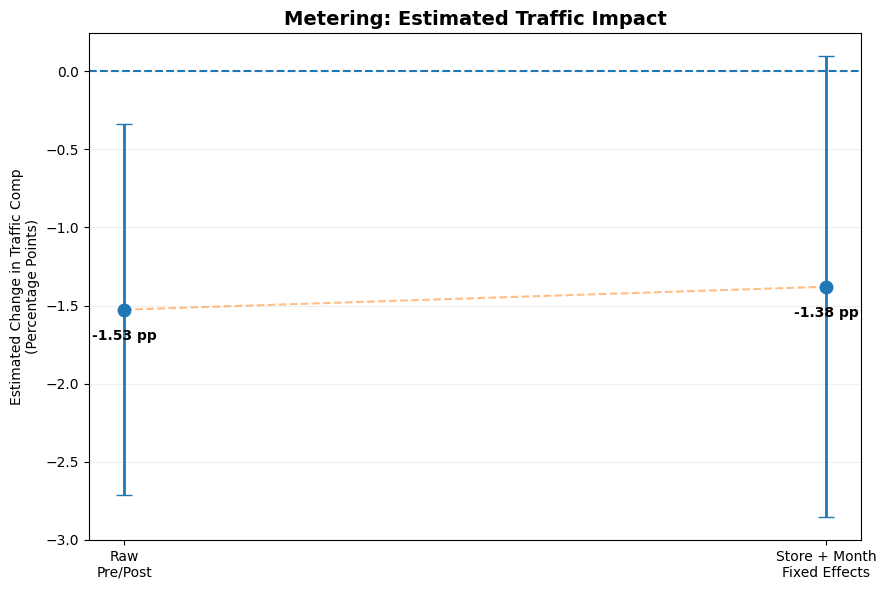

In [143]:
plot_ap_impact_progression(
    ap_progression,
    "SCA Receipt Checks"
)

plot_ap_impact_progression(
    ap_progression,
    "Metering"
)

In [144]:
# ============================================================
# FIXED-EFFECTS EVENT-STUDY PLOT
# ============================================================

def plot_fe_event_study(
    results,
    measure,
    pre_bin=-6,
    post_bin=6
):
    """
    Plot fixed-effects event-study coefficients
    with 95% confidence intervals.
    """

    temp = results.copy()

    x = temp["Event_Month"].to_numpy()

    estimate = (
        temp["Coefficient"].to_numpy()
        * 100
    )

    lower = (
        temp["CI_Lower"].to_numpy()
        * 100
    )

    upper = (
        temp["CI_Upper"].to_numpy()
        * 100
    )

    error_lower = (
        estimate - lower
    )

    error_upper = (
        upper - estimate
    )

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    # --------------------------------------------------------
    # EVENT COEFFICIENTS
    # --------------------------------------------------------

    ax.errorbar(
        x,
        estimate,
        yerr=[
            error_lower,
            error_upper
        ],
        fmt="o",
        capsize=4,
        linewidth=1.5,
        label="Event-Time Estimate"
    )

    ax.plot(
        x,
        estimate,
        linewidth=1,
        alpha=0.5
    )

    # --------------------------------------------------------
    # REFERENCE LINES
    # --------------------------------------------------------

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.5,
        label="No Traffic Effect"
    )

    ax.axvline(
        0,
        linestyle=":",
        linewidth=1.5,
        label="AP Implementation"
    )

    # --------------------------------------------------------
    # FORMATTING
    # --------------------------------------------------------

    ax.set_xticks(
        range(
            pre_bin,
            post_bin + 1
        )
    )

    ax.set_xlabel(
        "Months Relative to Implementation"
    )

    ax.set_ylabel(
        "Estimated Traffic Comp Difference\n"
        "vs. Month -1 (Percentage Points)"
    )

    ax.set_title(
        f"{measure}: Fixed-Effects Event Study",
        fontsize=14,
        fontweight="bold"
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

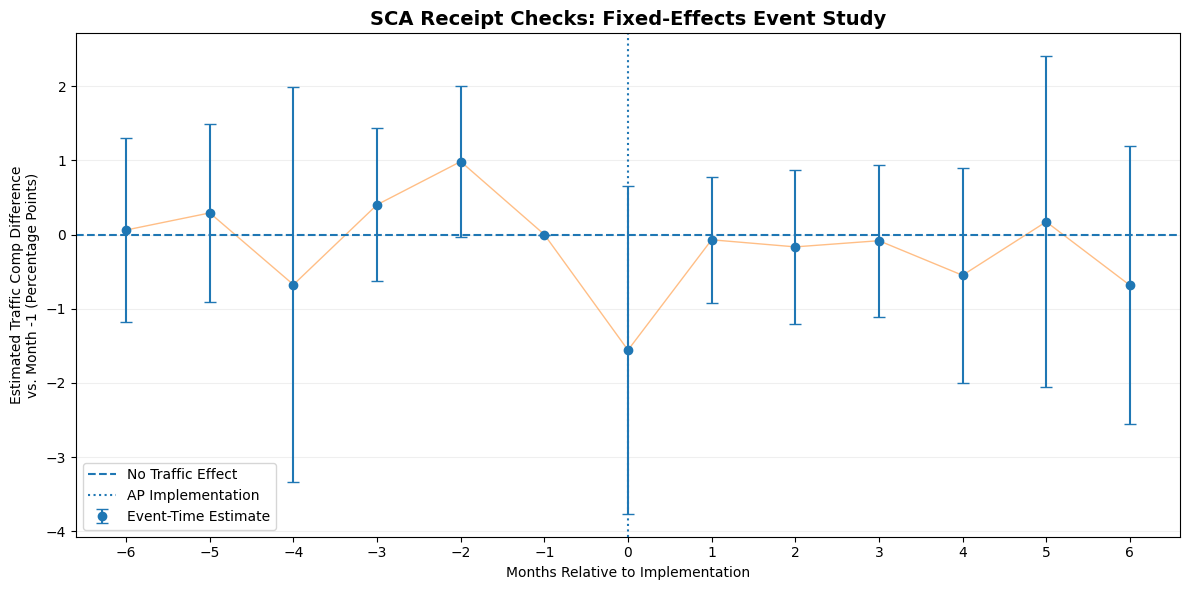

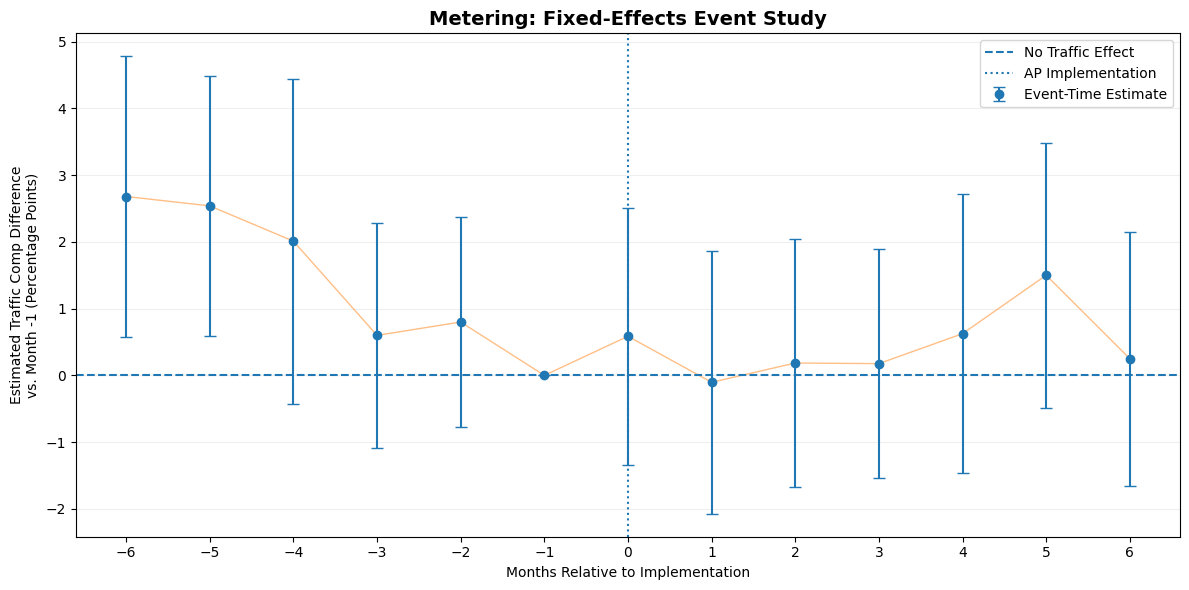

In [145]:
plot_fe_event_study(
    sca_event_results,
    "SCA Receipt Checks"
)

plot_fe_event_study(
    metering_event_results,
    "Metering"
)

The apparent traffic drag diminishes as confounding factors are accounted for, and the analysis finds no statistically significant evidence that SCA Receipt Checks or Metering caused a negative impact on traffic.